# Refined Cluster Evaluation — Materiais Recicláveis

**Objetivo:** Avaliar modelos de previsão de preço (R$/kg) usando a **clusterização por nome** (TF-IDF hierárquico + desambiguação por preço) e a **variável de setor CNAE** desenvolvidos no pipeline de preço justo.

**Diferença vs price_prediction_polen:**
- Usa `refine_outros` + `cluster_by_name` (TF-IDF hierárquico) em vez de `emergency_fix_outros` + `assign_price_tiers`
- Adiciona `emitter_sector` (classificação CNAE) como feature nos modelos
- Mantém o pipeline completo de avaliação: Walk-Forward CV, todos os modelos, breakdowns por estado/cluster/tier

### Pipeline
1. Carga e limpeza
2. Classificação de operações e materiais (TF-IDF matching)
3. Refinamento OUTROS + Clusterização por nome (TF-IDF hierárquico com desambiguação por preço)
4. Setor CNAE + Outlier removal
5. Feature engineering (lags, ciclicidade, macro, sazonalidade, setor)
6. Cluster optimizer (compara estratégias)
7. Walk-Forward CV (Linear, Ridge, RF, XGBoost, LightGBM + baselines)
8. Resultados: global, por estado, por cluster, por tier de qualidade
9. Feature importance + Diagnóstico de heterogeneidade
10. Tabela de preço justo + Previsão vs Real

In [150]:
%pip install xgboost lightgbm --quiet

Note: you may need to restart the kernel to use updated packages.


In [232]:
import os
from pathlib import Path

os.chdir(Path(__file__).parent if "__file__" in dir() else Path.cwd())
_NB_DIR = Path("/Users/lucascruz/Documents/GitHub/vizu-mono/projetos/polen")
if _NB_DIR.exists():
    os.chdir(_NB_DIR)

import pandas as pd
import numpy as np
import re
import unicodedata
import warnings
import json
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.sparse import hstack

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed — skipping XGBRegressor")

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("lightgbm not installed — skipping LGBMRegressor")

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
sns.set_style("whitegrid")

PRICE_COL = "unitpricekg_product"
VENDA_CATS = ["VENDA", "VENDA INTERESTADUAL"]
TFIDF_THRESHOLD = 0.25
MATCH_SCORE_MIN = 0.6
MIN_OBS_FAIR_PRICE = 5
PRICE_RATIO_THRESHOLD = 2.0
NAME_DIST_THRESHOLD = 0.50

PALETTE = ["#2C3E50", "#E74C3C", "#3498DB", "#27AE60", "#F39C12", "#9B59B6", "#1ABC9C", "#E67E22"]
GROUP_COLORS = {
    "PET": "#1f77b4", "PP": "#ff7f0e", "PEAD": "#2ca02c",
    "PS": "#d62728", "PE/FILME": "#9467bd", "PVC": "#8c564b",
    "BOPP/RAFIA": "#e377c2", "OUTROS": "#7f7f7f",
}

print("✓ Ambiente configurado")

✓ Ambiente configurado


## 1. Carga e Limpeza

In [233]:
df_invoices = pd.read_csv("products_invoices.csv")
df_estoque = pd.read_csv("consulta_estoque.csv")

# --- Limpeza: colunas desnecessárias ou >50% nulas ---
est_drop = ["_fivetran_synced", "_fivetran_deleted", "estoque_minimo", "reservado"]
est_null = df_estoque.columns[df_estoque.isnull().mean() > 0.5].tolist()
df_estoque = df_estoque.drop(columns=list(set(est_drop + est_null)), errors="ignore")

inv_drop = [
    "id_product", "fivetran_deleted_product",
    "id_operatorinvoice", "fivetran_deleted_operatorinvoice",
    "id_subsidiary", "fivetran_deleted_subsidiary", "companyid",
    "status_product", "product_invalidations", "product_nf",
    "licensecetesb", "sefaz_valida",
    "has_invoice_credit", "id_invoicecredit", "createdat_invoicecredit",
    "was_purchased", "purchaseordersids", "purchaseorders_codes",
    "was_compensation", "compensations_ids",
    "createdat_product", "createdat_operatorinvoice", "createdat_subsidiary",
    "danfe", "danfe_materials", "aditional_cpl_operatorinvoice",
    "isblocked_operatorinvoice", "volume_attention", "volume_attention_por_data",
    "invoice_in_offer",
    "emitterlegaldoc", "emitterlegalname", "emitterfantasyname",
    "emitterneighborhood", "emitternumber", "emitterphone",
    "emitterstreet", "emitterzipcode",
    "receiverlegaldoc", "receiverlegalname",
    "receivernumber", "receiverphone", "receiverstreet", "receiverzipcode",
    "status_subsidiary", "phone_subsidiary", "email_subsidiary",
    "address1_subsidiary", "neighbourhood_subsidiary",
    "number_subsidiary", "legalname_subsidiary", "cnpj_subsidiary",
    "zip_subsidiary",
]
inv_null = df_invoices.columns[df_invoices.isnull().mean() > 0.5].tolist()
df_invoices = df_invoices.drop(columns=list(set(inv_drop + inv_null)), errors="ignore")

df_invoices["emittedat_operatorinvoice"] = pd.to_datetime(
    df_invoices["emittedat_operatorinvoice"], errors="coerce"
)
df_invoices["year"] = df_invoices["emittedat_operatorinvoice"].dt.year
df_invoices["month"] = df_invoices["emittedat_operatorinvoice"].dt.month
df_invoices["year_month"] = df_invoices["emittedat_operatorinvoice"].dt.to_period("M")
df_invoices = df_invoices[df_invoices["year"].isin([2023, 2024, 2025])].copy()

print(f"✓ Notas carregadas: {len(df_invoices):,}")
print(f"  Estoque carregado: {len(df_estoque):,} produtos")

/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_54403/493153720.py:1: DtypeWarning: Columns (87,89,91,92,95) have mixed types. Specify dtype option on import or set low_memory=False.
  df_invoices = pd.read_csv("products_invoices.csv")


✓ Notas carregadas: 87,943
  Estoque carregado: 66 produtos


/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_54403/493153720.py:40: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_invoices["year_month"] = df_invoices["emittedat_operatorinvoice"].dt.to_period("M")


## 2. Classificação de Operações, Materiais e Setor CNAE

In [234]:
# ── Classificadores ──

def classify_natop(natop):
    if pd.isna(natop):
        return "OUTROS"
    s = str(natop).strip().lower()
    is_inter = any(kw in s for kw in [
        "interestadual", "inter estadual", "interstate",
        "fora do estado", "fora estado", "outros estados",
    ])
    if is_inter:
        if any(kw in s for kw in ["venda", "vda", "saida", "saída", "remessa", "sucata"]):
            return "VENDA INTERESTADUAL"
        if any(kw in s for kw in ["compra", "cpa", "entrada", "aquisicao", "aquisição"]):
            return "COMPRA INTERESTADUAL"
        return "OUTROS"
    if any(kw in s for kw in ["venda", "vda", "vnd"]):
        return "VENDA"
    if re.search(r"\bsaida\b|\bsaída\b", s) and not any(kw in s for kw in ["devolucao", "devolução", "retorno"]):
        return "VENDA"
    if any(kw in s for kw in ["compra", "cpa"]):
        return "COMPRA"
    if re.search(r"\bentrada\b", s) and not any(kw in s for kw in ["devolucao", "devolução", "retorno"]):
        return "COMPRA"
    if any(kw in s for kw in ["aquisicao", "aquisição"]):
        return "COMPRA"
    return "OUTROS"


def classify_material_group(text):
    if pd.isna(text):
        return "OUTROS"
    s = str(text).strip().upper()
    if "PEAD" in s:                              return "PEAD"
    if "PET" in s:                               return "PET"
    if "BOPP" in s or "RAFIA" in s:              return "BOPP/RAFIA"
    if "PP" in s:                                return "PP"
    if "PS" in s:                                return "PS"
    if "PVC" in s:                               return "PVC"
    if "PE " in s or "FILME" in s or s.startswith("PE"): return "PE/FILME"
    return "OUTROS"


def normalize_text(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return " ".join(s.split())


# ── Setor CNAE (from preco_justo_pipeline) ──

_CNAE_RE = re.compile(r'^\d{2}\.\d{2}-\d-\d{2}$')

def classify_cnae_sector(cnae):
    if pd.isna(cnae):
        return "DESCONHECIDO"
    s = str(cnae).strip()
    if not _CNAE_RE.match(s):
        return "DESCONHECIDO"
    div = s[:2]
    if div == "38":                          return "COLETA_RECICLAGEM"
    if div == "94" or div == "88":           return "COOPERATIVA"
    if s.startswith("46.87") or s.startswith("46.86"):
        return "COMERCIO_ATACADO"
    if div in ("22", "17", "23", "24", "25",
               "20", "28", "13", "15", "26",
               "27", "29", "30", "31", "32", "33"):
        return "INDUSTRIA"
    if div.startswith("4"):                  return "COMERCIO"
    return "OUTROS_SETOR"


# ── Sinônimos para normalização TF-IDF ──

SYNONYMS = {
    "LATAS DE ALUMINIO": "LATINHAS", "LATA DE ALUMINIO": "LATINHAS",
    "LATINHAS DE ALUMINIO": "LATINHAS", "LATINHA DE ALUMINIO": "LATINHAS",
    "LATA ALUMINIO": "LATINHAS", "LATAS ALUMINIO": "LATINHAS",
    "ALUMINIO LATA": "LATINHAS", "LATINHA": "LATINHAS",
    "SACOLAS": "SACOLINHA", "SACOLA": "SACOLINHA", "SACOLINHAS": "SACOLINHA",
    "FILME PEBD": "FILME", "FILME PE": "FILME", "PEBD": "PE",
    "RAFFIA": "RAFIA", "BIG BAGS": "RAFIA", "BIG BAG": "RAFIA", "BIGBAG": "RAFIA",
    "COPOS": "COPINHO", "COPO": "COPINHO",
    "POTES MARGARINA": "MARGARINA", "POTE MARGARINA": "MARGARINA",
    "POTE DE MARGARINA": "MARGARINA",
    "BALDES": "BALDE BACIA", "BALDE": "BALDE BACIA",
    "BACIAS": "BALDE BACIA", "BACIA": "BALDE BACIA",
    "TAMPAS": "TAMPINHA", "TAMPA": "TAMPINHA", "TAMPINHAS": "TAMPINHA",
    "PRE-FORMA": "PREFORMA", "PRE FORMA": "PREFORMA",
    "BANDEJAS": "BANDEJA",
    "APARAS DE": "SUCATA DE", "APARA DE": "SUCATA DE",
    "APARAS": "SUCATA", "APARA": "SUCATA",
    "POS CONSUMO": "", "POS-CONSUMO": "", "PRE CONSUMO": "", "PRE-CONSUMO": "",
    "RECICLADO": "", "RECICLADA": "", "TRITURADO": "", "TRITURADA": "",
    "MOIDO": "", "MOIDA": "",
}
_SORTED_SYNS = sorted(SYNONYMS.items(), key=lambda x: -len(x[0]))

def expand_synonyms(text):
    for old, new in _SORTED_SYNS:
        text = re.sub(r'\b' + re.escape(old) + r'\b', new, text)
    return " ".join(text.split())

print("✓ Classificadores definidos")

✓ Classificadores definidos


In [235]:
# ── Aplicar classificações ──

df_invoices["natop_category"] = df_invoices["natop_operatorinvoice"].apply(classify_natop)
df_estoque["material_group"] = df_estoque["c_descricao"].apply(classify_material_group)

mask = (
    df_invoices["material"].notna()
    & (df_invoices["material"].str.strip() != "")
    & (df_invoices["material"].str.strip().str.lower() != "unknown")
    & df_invoices["description_product"].notna()
    & (df_invoices["description_product"].str.strip() != "")
    & (df_invoices["natop_category"] != "OUTROS")
)
df_clean = df_invoices[mask].copy()

# ── TF-IDF Matching contra catálogo de estoque ──

estoque_products = sorted(set(
    p for p in df_estoque["c_descricao"].dropna().apply(normalize_text).unique() if p
))
estoque_expanded = [expand_synonyms(p) for p in estoque_products]
estoque_to_group = {}
for _, row in df_estoque.dropna(subset=["c_descricao"]).iterrows():
    key = normalize_text(row["c_descricao"])
    if key:
        estoque_to_group[key] = row["material_group"]

unique_descs = sorted(set(
    d for d in df_clean["description_product"].dropna().apply(normalize_text).unique() if d
))
descs_expanded = [expand_synonyms(d) for d in unique_descs]

all_expanded = estoque_expanded + descs_expanded
n_est = len(estoque_expanded)

vec_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
tfidf_char = vec_char.fit_transform(all_expanded)
sim_char = cosine_similarity(tfidf_char[n_est:], tfidf_char[:n_est])

vec_word = TfidfVectorizer(analyzer="word", ngram_range=(1, 2))
tfidf_word = vec_word.fit_transform(all_expanded)
sim_word = cosine_similarity(tfidf_word[n_est:], tfidf_word[:n_est])

sim_matrix = 0.5 * sim_char + 0.5 * sim_word

match_map = {}
for i, desc in enumerate(unique_descs):
    best_idx = sim_matrix[i].argmax()
    best_score = sim_matrix[i, best_idx]
    if best_score >= TFIDF_THRESHOLD:
        match_map[desc] = (estoque_products[best_idx], round(best_score, 3))
    else:
        match_map[desc] = ("SEM CORRESPONDENCIA", round(best_score, 3))

df_clean["desc_normalized"] = df_clean["description_product"].apply(normalize_text)
df_clean["estoque_product"] = df_clean["desc_normalized"].map(
    lambda d: match_map.get(d, ("SEM CORRESPONDENCIA", 0))[0]
)
df_clean["match_score"] = df_clean["desc_normalized"].map(
    lambda d: match_map.get(d, ("SEM CORRESPONDENCIA", 0))[1]
)
df_clean["material_group"] = df_clean["desc_normalized"].map(
    lambda d: estoque_to_group.get(match_map.get(d, ("", 0))[0], None)
)
mask_no_group = df_clean["material_group"].isna()
df_clean.loc[mask_no_group, "material_group"] = (
    df_clean.loc[mask_no_group, "material"].apply(classify_material_group)
)

df_matched = df_clean[df_clean["match_score"] > MATCH_SCORE_MIN].copy()

# ── Preço válido ──
df_price = df_matched.dropna(subset=[PRICE_COL]).copy()
df_price = df_price[df_price[PRICE_COL] > 0]

df_price_clean = df_price.copy()

# ── Setor CNAE ──
df_price_clean["emitter_sector"] = df_price_clean["emittercnae"].apply(classify_cnae_sector)
df_price_clean["receiver_sector"] = df_price_clean["receivercnae"].apply(classify_cnae_sector)

print(f"✓ Pipeline de limpeza completo")
print(f"  Matched (score > {MATCH_SCORE_MIN}): {len(df_matched):,}")
print(f"  Com preço válido: {len(df_price_clean):,}")
print(f"\nDistribuição de setores (emitter):")
print(df_price_clean["emitter_sector"].value_counts())

✓ Pipeline de limpeza completo
  Matched (score > 0.6): 21,269
  Com preço válido: 21,185

Distribuição de setores (emitter):
emitter_sector
COLETA_RECICLAGEM    7913
COOPERATIVA          7746
COMERCIO_ATACADO     4950
INDUSTRIA             457
COMERCIO               78
OUTROS_SETOR           41
Name: count, dtype: int64


## 3. Clusterização por Nome (TF-IDF Hierárquico)

Clusterização direta por similaridade textual dos nomes de produtos, dentro de cada `material_group`:
- **TF-IDF hierárquico:** char n-grams (2-4) + word n-grams (1-2) → distância cosseno → linkage average
- **Desambiguação por preço:** quando a razão de preços dentro de um cluster excede `PRICE_RATIO_THRESHOLD`, split via KMeans em log-price

In [236]:
def cluster_by_name(df, group_col="material_group"):
    """Cluster products by name similarity (TF-IDF hierarchical) with price disambiguation."""
    df = df.copy()
    df["material_cluster"] = df[group_col]

    for group_name, group_df in df.groupby(group_col):
        prod_stats = (
            group_df.groupby("estoque_product")
            .agg(median_price=(PRICE_COL, "median"), count=(PRICE_COL, "count"))
            .reset_index()
        )
        if len(prod_stats) < 2:
            product = prod_stats["estoque_product"].iloc[0]
            df.loc[df[group_col] == group_name, "material_cluster"] = f"{group_name}::{product}"
            continue

        names = prod_stats["estoque_product"].apply(normalize_text).values

        vec_c = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
        vec_w = TfidfVectorizer(analyzer="word", ngram_range=(1, 2))
        tfidf_c = vec_c.fit_transform(names)
        tfidf_w = vec_w.fit_transform(names)
        X = hstack([tfidf_c, tfidf_w])

        dist = pdist(X.toarray(), metric="cosine")
        dist = np.nan_to_num(dist, nan=0.0)
        Z = linkage(dist, method="average")
        labels = fcluster(Z, t=NAME_DIST_THRESHOLD, criterion="distance")

        prod_stats["name_cluster"] = labels

        # Post-hoc price split
        final_labels = prod_stats["name_cluster"].copy()
        next_label = labels.max() + 1

        for cl in prod_stats["name_cluster"].unique():
            cl_mask = prod_stats["name_cluster"] == cl
            cl_prods = prod_stats[cl_mask]
            if len(cl_prods) < 2:
                continue
            max_p = cl_prods["median_price"].max()
            min_p = cl_prods["median_price"].min()
            if min_p > 0 and max_p / min_p > PRICE_RATIO_THRESHOLD:
                log_prices = np.log1p(cl_prods["median_price"].values).reshape(-1, 1)
                km = KMeans(n_clusters=2, n_init=10, random_state=42)
                sub_labels = km.fit_predict(log_prices)
                for sl in range(1, 2):
                    idx_positions = cl_prods.index[sub_labels == sl]
                    final_labels.loc[idx_positions] = next_label
                    next_label += 1

        prod_stats["final_cluster"] = final_labels

        cluster_names = {}
        for cl_id in prod_stats["final_cluster"].unique():
            cl_prods = prod_stats[prod_stats["final_cluster"] == cl_id]
            top_product = cl_prods.sort_values("count", ascending=False).iloc[0]["estoque_product"]
            cluster_names[cl_id] = f"{group_name}::{top_product}"

        product_to_cluster = dict(
            zip(prod_stats["estoque_product"], prod_stats["final_cluster"].map(cluster_names))
        )
        mask = df[group_col] == group_name
        df.loc[mask, "material_cluster"] = df.loc[mask, "estoque_product"].map(product_to_cluster)
        df.loc[mask & df["material_cluster"].isna(), "material_cluster"] = group_name

    return df


# ── Aplicar clusterização por nome diretamente em material_group ──
df_price_clean = cluster_by_name(df_price_clean)

print(f"✓ Clusterização completa")
print(f"  material_group:   {df_price_clean['material_group'].nunique()} grupos originais")
print(f"  material_cluster: {df_price_clean['material_cluster'].nunique()} clusters (TF-IDF + preço)")
print(f"\n  Clusters por grupo:")
for g in sorted(df_price_clean['material_group'].unique()):
    n_clusters = df_price_clean[df_price_clean['material_group'] == g]['material_cluster'].nunique()
    print(f"    {g}: {n_clusters} clusters")

✓ Clusterização completa
  material_group:   8 grupos originais
  material_cluster: 42 clusters (TF-IDF + preço)

  Clusters por grupo:
    BOPP/RAFIA: 2 clusters
    OUTROS: 5 clusters
    PE/FILME: 4 clusters
    PEAD: 7 clusters
    PET: 12 clusters
    PP: 9 clusters
    PS: 2 clusters
    PVC: 1 clusters


In [237]:
# ── Outlier removal por IQR (após clusterização) ──

def remove_outliers_iqr(df, col, groupby_cols, k=1.5):
    clean_dfs = []
    for _, grp in df.groupby(groupby_cols):
        q1 = grp[col].quantile(0.25)
        q3 = grp[col].quantile(0.75)
        iqr = q3 - q1
        mask = (grp[col] >= q1 - k * iqr) & (grp[col] <= q3 + k * iqr)
        clean_dfs.append(grp[mask])
    return pd.concat(clean_dfs, ignore_index=True)

# Filter to VENDAS and apply outlier removal by material_cluster
df_price_clean = df_price_clean[df_price_clean["natop_category"].isin(VENDA_CATS)].copy()
df_price_clean["side"] = "VENDAS"

n_before = len(df_price_clean)
df_price_clean = remove_outliers_iqr(df_price_clean, PRICE_COL, ["material_cluster", "emitterstateuf"])
n_after = len(df_price_clean)

print(f"✓ Outlier removal por [material_cluster, emitterstateuf] (k=1.5 IQR)")
print(f"  Antes: {n_before:,}")
print(f"  Após:  {n_after:,}")
print(f"  Removidos: {n_before - n_after:,} ({(n_before - n_after) / n_before * 100:.1f}%)")

# ── Eliminar materiais com menos de 10 ocorrências ──
MIN_MAT_OBS = 10
mat_counts = df_price_clean["estoque_product"].value_counts()
rare_materials = mat_counts[mat_counts < MIN_MAT_OBS].index.tolist()
n_before_mat = len(df_price_clean)
df_price_clean = df_price_clean[~df_price_clean["estoque_product"].isin(rare_materials)].copy()

print(f"\n✓ Filtro de materiais raros (< {MIN_MAT_OBS} ocorrências)")
print(f"  Materiais removidos: {len(rare_materials)} de {len(mat_counts)}")
print(f"  Linhas antes: {n_before_mat:,}")
print(f"  Linhas após:  {len(df_price_clean):,}")

# ── Eliminar clusters com menos de 50 observações ──
MIN_OBS = 50
cluster_counts = df_price_clean["material_cluster"].value_counts()
small_clusters = cluster_counts[cluster_counts < MIN_OBS].index.tolist()
n_before_filter = len(df_price_clean)
df_price_clean = df_price_clean[~df_price_clean["material_cluster"].isin(small_clusters)].copy()

print(f"\n✓ Filtro de clusters pequenos (< {MIN_OBS} obs)")
print(f"  Clusters removidos: {len(small_clusters)} de {len(cluster_counts)}")
if small_clusters:
    print(f"  Nomes: {small_clusters}")
print(f"  Linhas antes: {n_before_filter:,}")
print(f"  Linhas após:  {len(df_price_clean):,}")
print(f"  Clusters restantes: {df_price_clean['material_cluster'].nunique()}")

✓ Outlier removal por [material_cluster, emitterstateuf] (k=1.5 IQR)
  Antes: 20,793
  Após:  19,601
  Removidos: 1,192 (5.7%)

✓ Filtro de materiais raros (< 10 ocorrências)
  Materiais removidos: 12 de 54
  Linhas antes: 19,601
  Linhas após:  19,543

✓ Filtro de clusters pequenos (< 50 obs)
  Clusters removidos: 9 de 36
  Nomes: ['PET::SUCATA DE PET LEITOSO', 'PEAD::PEAD BOMBONA', 'PET::PET AZEITE', 'PET::SUCATA DE PET BANDEJA', 'PE/FILME::PE CANELA', 'PET::FITA PET VERDE', 'PEAD::PEAD CRISTAL', 'PP::FITA PP BRANCA', 'PE/FILME::SUCATA DE FILME CANELA']
  Linhas antes: 19,543
  Linhas após:  19,237
  Clusters restantes: 27


## 3b. Visualização da Clusterização

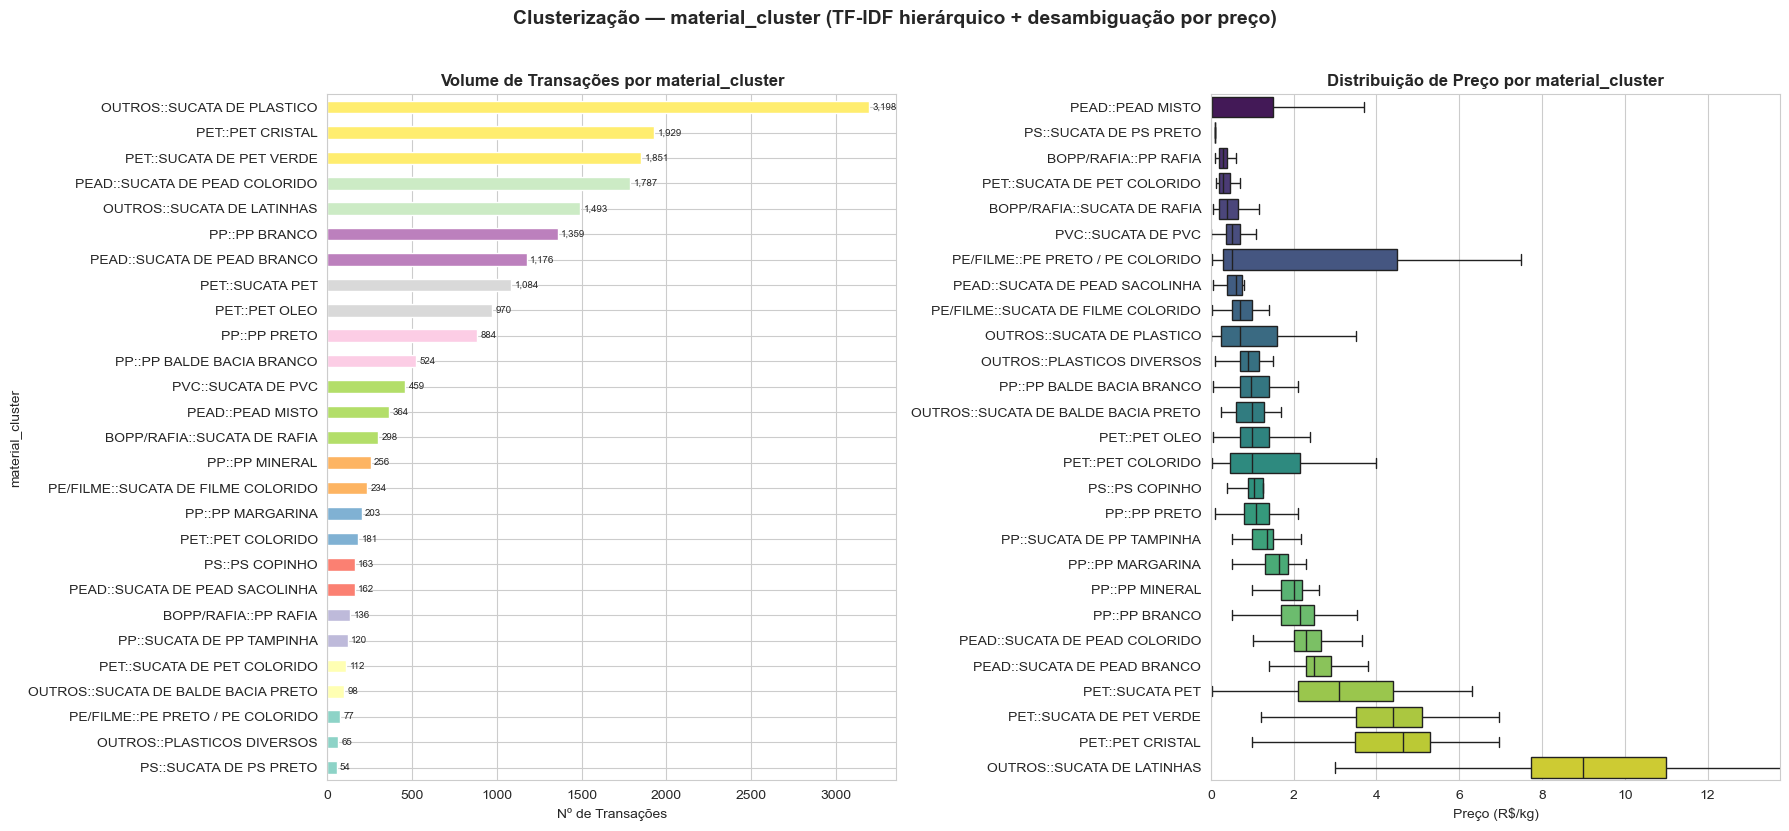


Cluster                                                  n  Mediana     CV
───────────────────────────────────────────────────────────────────────────
  PEAD::PEAD MISTO                                     364    0.02  1.364
  PS::SUCATA DE PS PRETO                                54    0.10  0.503
  BOPP/RAFIA::PP RAFIA                                 136    0.30 10.079
  PET::SUCATA DE PET COLORIDO                          112    0.30  1.352
  BOPP/RAFIA::SUCATA DE RAFIA                          298    0.40  0.522
  PVC::SUCATA DE PVC                                   459    0.50  0.765
  PE/FILME::PE PRETO / PE COLORIDO                      77    0.52  1.198
  PEAD::SUCATA DE PEAD SACOLINHA                       162    0.60  0.431
  PE/FILME::SUCATA DE FILME COLORIDO                   234    0.70  0.393
  OUTROS::SUCATA DE PLASTICO                         3,198    0.70  1.123
  OUTROS::PLASTICOS DIVERSOS                            65    0.90  0.424
  PP::PP BALDE BACIA BRANCO       

In [238]:
# ── Visualização: material_cluster (clusterização final) ──
df_vendas_viz = df_price_clean[df_price_clean["natop_category"].isin(VENDA_CATS)].copy()
tiers = df_vendas_viz["material_cluster"].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(tiers) * 0.3)))

ax = axes[0]
tier_colors = plt.cm.Set3(np.linspace(0, 1, len(tiers)))
tiers.plot(kind="barh", ax=ax, color=tier_colors, edgecolor="white")
ax.set_title("Volume de Transações por material_cluster", fontweight="bold")
ax.set_xlabel("Nº de Transações")
for i, v in enumerate(tiers):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=7)

ax = axes[1]
order = df_vendas_viz.groupby("material_cluster")[PRICE_COL].median().sort_values().index
sns.boxplot(data=df_vendas_viz, y="material_cluster", x=PRICE_COL, order=order, ax=ax,
            palette="viridis", fliersize=0, showfliers=False)
ax.set_title("Distribuição de Preço por material_cluster", fontweight="bold")
ax.set_xlabel("Preço (R$/kg)")
ax.set_ylabel("")
x_max = df_vendas_viz[PRICE_COL].quantile(0.99) * 1.1
ax.set_xlim(0, x_max)

plt.suptitle("Clusterização — material_cluster (TF-IDF hierárquico + desambiguação por preço)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'Cluster':<50s} {'n':>7s} {'Mediana':>8s} {'CV':>6s}")
print("─" * 75)
for g in df_vendas_viz.groupby("material_cluster")[PRICE_COL].median().sort_values().index:
    sub = df_vendas_viz[df_vendas_viz["material_cluster"] == g]
    cv = sub[PRICE_COL].std() / sub[PRICE_COL].mean() if sub[PRICE_COL].mean() > 0 else 0
    print(f"  {g:<48s} {len(sub):>7,} {sub[PRICE_COL].median():>7.2f} {cv:>6.3f}")

## 3c. Distribuição de Setores por Cluster


Setor × Grupo (top 20 pares por volume):


,emitter_sector,material_group,n,median_price,cv
4,COLETA_RECICLAGEM,PET,2247,3.20000,0.607922
1,COLETA_RECICLAGEM,OUTROS,2055,1.50000,1.142640
15,COMERCIO_ATACADO,PET,1891,4.80000,0.340324
22,COOPERATIVA,PEAD,1745,2.40000,0.399305
24,COOPERATIVA,PP,1718,1.65000,0.439962
23,COOPERATIVA,PET,1572,2.05000,0.614416
12,COMERCIO_ATACADO,OUTROS,1441,5.20000,0.839286
20,COOPERATIVA,OUTROS,1292,0.80000,1.376160
5,COLETA_RECICLAGEM,PP,1207,1.40000,2.817399
3,COLETA_RECICLAGEM,PEAD,1062,2.26465,0.343876


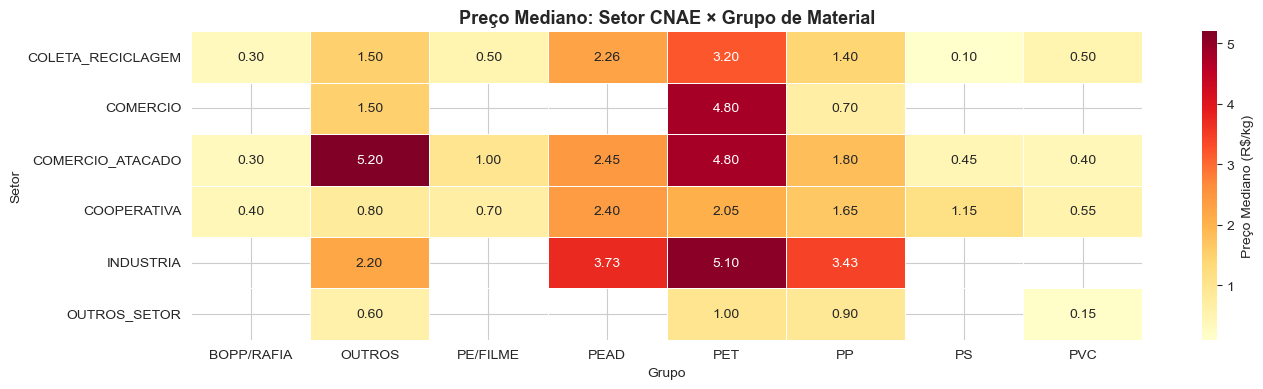


Preço mediano por setor × estado:


count  median      mean
emitter_sector    emitterstateuf                         
COLETA_RECICLAGEM GO                520   7.730  5.595865
COMERCIO_ATACADO  ES                763   6.550  7.238523
INDUSTRIA         GO                 94   6.500  5.976915
                  BA                 85   6.500  4.658824
COMERCIO_ATACADO  PE                876   5.100  5.543550
...                                 ...     ...       ...
COOPERATIVA       AM                  8   0.175  0.187500
                  PA                  8   0.130  0.117500
COLETA_RECICLAGEM RO                  1   0.100  0.100000
COOPERATIVA       MT                  1   0.080  0.080000
COLETA_RECICLAGEM AC                  1   0.050  0.050000

[72 rows x 3 columns]

In [239]:
# ── Setor × Cluster cross-tabulation ──
df_vendas_viz = df_price_clean[df_price_clean["natop_category"].isin(VENDA_CATS)].copy()

sector_stats = (
    df_vendas_viz.groupby(["emitter_sector", "material_group"])
    .agg(
        n=(PRICE_COL, "count"),
        median_price=(PRICE_COL, "median"),
        cv=(PRICE_COL, lambda x: x.std() / x.mean() if x.mean() > 0 else 0),
    ).reset_index().sort_values("n", ascending=False)
)

print(f"\nSetor × Grupo (top 20 pares por volume):")
display(sector_stats.head(20))

# Heatmap: preço mediano por setor × grupo
price_pivot = df_vendas_viz.groupby(["emitter_sector", "material_group"])[PRICE_COL].median().unstack(fill_value=np.nan)
if not price_pivot.empty:
    fig, ax = plt.subplots(figsize=(max(14, len(price_pivot.columns) * 1.2), max(4, len(price_pivot) * 0.5)))
    sns.heatmap(price_pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
                linewidths=0.5, cbar_kws={"label": "Preço Mediano (R$/kg)"})
    ax.set_title("Preço Mediano: Setor CNAE × Grupo de Material", fontsize=13, fontweight="bold")
    ax.set_ylabel("Setor")
    ax.set_xlabel("Grupo")
    plt.tight_layout()
    plt.show()

# Median price by sector × state
sector_price = (
    df_vendas_viz.groupby(["emitter_sector", "emitterstateuf"])[PRICE_COL]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)
print(f"\nPreço mediano por setor × estado:")
display(sector_price)

## 4. Definição de Quality Tiers

In [240]:
# Data quality tiers
ALL_MONTHS = pd.period_range("2023-01", "2025-12", freq="M")
TOTAL_MONTHS = len(ALL_MONTHS)

def quality_tier(row):
    if row["n_months"] >= 24 and row["n_rows"] >= 100:
        return "A (excellent)"
    elif row["n_months"] >= 12 and row["n_rows"] >= 30:
        return "B (good)"
    elif row["n_months"] >= 6 and row["n_rows"] >= 10:
        return "C (fair)"
    else:
        return "D (insufficient)"

print(f"✓ Quality tiers definidos")
print(f"  Dados disponíveis: {len(df_price_clean):,} registros (pós outlier removal)")
print

✓ Quality tiers definidos
  Dados disponíveis: 19,237 registros (pós outlier removal)


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

## 5. Feature Engineering — Aggregação Mensal + Macro + Setor

Features:
- Ciclicidade: `month_sin`, `month_cos`
- Lags: mediana 3m e 6m
- Volume: `n_transactions`, `vol_lag_3m`
- Macro: `usd_brl_mean` (PTAX), `ipca_monthly_pct`, `ipca_acc`
- Sazonalidade regional: `seasonal_idx`
- Heterogeneidade: `n_products_in_cluster`, `price_spread_90_10`, `product_concentration`
- **Setor CNAE:** `sector_encoded` (setor dominante do cluster)

In [241]:
# ── Build monthly datasets for multiple clustering strategies ──

CLUSTER_KEYS = ['material_group', 'material_cluster']
monthly_datasets = {}

for cluster_key in CLUSTER_KEYS:
    m = (
        df_price_clean.groupby([cluster_key, "emitterstateuf", "side", "year", "month"])
        .agg(
            price_median=(PRICE_COL, "median"),
            price_mean=(PRICE_COL, "mean"),
            price_q25=(PRICE_COL, lambda x: x.quantile(0.25)),
            price_q75=(PRICE_COL, lambda x: x.quantile(0.75)),
            price_std=(PRICE_COL, "std"),
            n_transactions=(PRICE_COL, "count"),
        ).reset_index()
    )
    m["price_std"] = m["price_std"].fillna(0)
    m["price_fair"] = m.apply(
        lambda row: row["price_median"]
        if row["price_median"] == 0 or abs(row["price_mean"] - row["price_median"]) / max(row["price_median"], 0.01) > 0.2
        else (row["price_q25"] + row["price_q75"]) / 2,
        axis=1,
    )
    m["cv"] = np.where(m["price_mean"] > 0, m["price_std"] / m["price_mean"], 0)
    monthly_datasets[cluster_key] = m
    print(f"{cluster_key}: {len(m)} rows, avg CV: {m['cv'].mean():.3f}, groups: {m[cluster_key].nunique()}")

# Start with material_cluster (will be validated by optimizer)
best_cluster_col = "material_cluster"
monthly = monthly_datasets[best_cluster_col].copy()

# Cyclical month encoding
monthly["month_sin"] = np.sin(2 * np.pi * monthly["month"] / 12)
monthly["month_cos"] = np.cos(2 * np.pi * monthly["month"] / 12)

monthly = monthly.sort_values([best_cluster_col, "emitterstateuf", "side", "year", "month"]).reset_index(drop=True)
monthly["date"] = pd.to_datetime(monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2) + "-01")

# Lag features
lag_dfs = []
for (grp, state, side), sub in monthly.groupby([best_cluster_col, "emitterstateuf", "side"]):
    sub = sub.sort_values("date").copy()
    sub["lag_1m"] = sub["price_median"].shift(1)
    sub["lag_3m"] = sub["price_median"].shift(1).rolling(3, min_periods=1).median()
    sub["lag_6m"] = sub["price_median"].shift(1).rolling(6, min_periods=1).median()
    sub["vol_lag_3m"] = sub["n_transactions"].shift(1).rolling(3, min_periods=1).mean()
    lag_dfs.append(sub)

monthly = pd.concat(lag_dfs, ignore_index=True)
monthly_feat = monthly.dropna(subset=["lag_1m"]).copy()

print(f"\nMonthly rows ({best_cluster_col}): {len(monthly)}")
print(f"With lag features: {len(monthly_feat)}")

material_group: 2047 rows, avg CV: 0.324, groups: 8
material_cluster: 3719 rows, avg CV: 0.166, groups: 27

Monthly rows (material_cluster): 3719
With lag features: 3445


In [242]:
# ── Fetch macro features: PTAX + IPCA ──

ptax_url = (
    "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
    "CotacaoDolarPeriodo(dataInicial=@di,dataFinalCotacao=@df)"
    "?@di='01-01-2023'&@df='12-31-2025'"
    "&$select=cotacaoVenda,dataHoraCotacao&$format=json&$top=10000"
)

try:
    with urllib.request.urlopen(ptax_url, timeout=30) as resp:
        ptax_raw = json.loads(resp.read().decode("utf-8"))["value"]
    df_ptax = pd.DataFrame(ptax_raw)
    df_ptax["date"] = pd.to_datetime(df_ptax["dataHoraCotacao"])
    df_ptax["year"] = df_ptax["date"].dt.year
    df_ptax["month"] = df_ptax["date"].dt.month
    ptax_monthly = (
        df_ptax.groupby(["year", "month"])["cotacaoVenda"]
        .mean().reset_index()
        .rename(columns={"cotacaoVenda": "usd_brl_mean"})
    )
    ptax_monthly["usd_brl_mean"] = ptax_monthly["usd_brl_mean"].round(4)
    print(f"PTAX: {len(ptax_monthly)} meses carregados")
except Exception as e:
    print(f"ERRO ao buscar PTAX: {e}")
    ptax_monthly = pd.DataFrame(columns=["year", "month", "usd_brl_mean"])

ipca_url = (
    "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados"
    "?formato=json&dataInicial=01/01/2023&dataFinal=31/12/2025"
)

try:
    req = urllib.request.Request(ipca_url, headers={"Accept": "application/json"})
    with urllib.request.urlopen(req, timeout=30) as resp:
        ipca_raw = json.loads(resp.read().decode("utf-8"))
    df_ipca = pd.DataFrame(ipca_raw)
    df_ipca["data"] = pd.to_datetime(df_ipca["data"], format="%d/%m/%Y")
    df_ipca["year"] = df_ipca["data"].dt.year
    df_ipca["month"] = df_ipca["data"].dt.month
    df_ipca["ipca_monthly_pct"] = df_ipca["valor"].astype(float)
    df_ipca = df_ipca.sort_values("data")
    df_ipca["ipca_acc"] = (1 + df_ipca["ipca_monthly_pct"] / 100).cumprod() * 100
    ipca_monthly = df_ipca[["year", "month", "ipca_monthly_pct", "ipca_acc"]].copy()
    print(f"IPCA: {len(ipca_monthly)} meses carregados")
except Exception as e:
    print(f"ERRO ao buscar IPCA: {e}")
    ipca_monthly = pd.DataFrame(columns=["year", "month", "ipca_monthly_pct", "ipca_acc"])

# Merge macro features
monthly_feat = monthly_feat.merge(ptax_monthly, on=["year", "month"], how="left")
monthly_feat = monthly_feat.merge(ipca_monthly, on=["year", "month"], how="left")

for col in ["usd_brl_mean", "ipca_monthly_pct", "ipca_acc"]:
    if col in monthly_feat.columns:
        monthly_feat[col] = monthly_feat[col].ffill().bfill()

print(f"\nMacro features merged. Shape: {monthly_feat.shape}")

PTAX: 36 meses carregados
IPCA: 36 meses carregados

Macro features merged. Shape: (3445, 23)


In [243]:
# ── Regional seasonality ──
train_mask = monthly_feat["year"].isin([2023, 2024])

group_state_mean = (
    monthly_feat[train_mask]
    .groupby([best_cluster_col, "emitterstateuf", "side"])["price_median"]
    .mean()
)
group_state_month_mean = (
    monthly_feat[train_mask]
    .groupby([best_cluster_col, "emitterstateuf", "side", "month"])["price_median"]
    .mean()
)
seasonal_index = (group_state_month_mean / group_state_mean).reset_index()
seasonal_index.columns = [best_cluster_col, "emitterstateuf", "side", "month", "seasonal_idx"]

monthly_feat = monthly_feat.merge(
    seasonal_index, on=[best_cluster_col, "emitterstateuf", "side", "month"], how="left"
)
monthly_feat["seasonal_idx"] = monthly_feat["seasonal_idx"].fillna(1.0)

# ── Cluster heterogeneity features ──
heterogeneity = (
    df_price_clean.groupby([best_cluster_col, 'emitterstateuf'])
    .agg(
        n_products_in_cluster=('estoque_product', 'nunique'),
        price_spread_90_10=(PRICE_COL, lambda x: x.quantile(0.9) - x.quantile(0.1)),
    )
    .reset_index()
)

monthly_feat = monthly_feat.merge(
    heterogeneity, on=[best_cluster_col, 'emitterstateuf'], how='left'
)

# Product concentration (Herfindahl)
prod_counts = (
    df_price_clean.groupby([best_cluster_col, 'emitterstateuf', 'year', 'month', 'estoque_product'])
    .size().reset_index(name='cnt')
)
totals = prod_counts.groupby([best_cluster_col, 'emitterstateuf', 'year', 'month'])['cnt'].transform('sum')
prod_counts['share'] = prod_counts['cnt'] / totals
concentration = (
    prod_counts.groupby([best_cluster_col, 'emitterstateuf', 'year', 'month'])
    .apply(lambda g: (g['share'] ** 2).sum(), include_groups=False)
    .reset_index(name='product_concentration')
)

monthly_feat = monthly_feat.merge(
    concentration, on=[best_cluster_col, 'emitterstateuf', 'year', 'month'], how='left'
)

monthly_feat['product_concentration'] = monthly_feat['product_concentration'].fillna(1.0)
monthly_feat['n_products_in_cluster'] = monthly_feat['n_products_in_cluster'].fillna(1)
monthly_feat['price_spread_90_10'] = monthly_feat['price_spread_90_10'].fillna(0)

# ── Sector feature: dominant sector per cluster×state ──
sector_dominant = (
    df_price_clean.groupby([best_cluster_col, 'emitterstateuf'])['emitter_sector']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'emitter_sector': 'dominant_sector'})
)

monthly_feat = monthly_feat.merge(
    sector_dominant, on=[best_cluster_col, 'emitterstateuf'], how='left'
)
monthly_feat['dominant_sector'] = monthly_feat['dominant_sector'].fillna('DESCONHECIDO')

# Encode sector as numeric
sector_map = {s: i for i, s in enumerate(sorted(monthly_feat['dominant_sector'].unique()))}
monthly_feat['sector_encoded'] = monthly_feat['dominant_sector'].map(sector_map)

# Sector proportion features: share of each sector in the cluster
sector_shares = (
    df_price_clean.groupby([best_cluster_col, 'emitterstateuf', 'emitter_sector'])
    .size().reset_index(name='cnt')
)
sector_totals = sector_shares.groupby([best_cluster_col, 'emitterstateuf'])['cnt'].transform('sum')
sector_shares['share'] = sector_shares['cnt'] / sector_totals

# Get share of top sector (industry concentration)
sector_hhi = (
    sector_shares.groupby([best_cluster_col, 'emitterstateuf'])
    .apply(lambda g: g['share'].max(), include_groups=False)
    .reset_index(name='sector_concentration')
)

monthly_feat = monthly_feat.merge(
    sector_hhi, on=[best_cluster_col, 'emitterstateuf'], how='left'
)
monthly_feat['sector_concentration'] = monthly_feat['sector_concentration'].fillna(1.0)

print(f"✓ Features completas")
print(f"  seasonal_idx range: {monthly_feat['seasonal_idx'].min():.3f} – {monthly_feat['seasonal_idx'].max():.3f}")
print(f"  n_products_in_cluster mean: {monthly_feat['n_products_in_cluster'].mean():.1f}")
print(f"  sector_encoded unique: {monthly_feat['sector_encoded'].nunique()}")
print(f"  sector_concentration mean: {monthly_feat['sector_concentration'].mean():.3f}")
print(f"\nDominant sector distribution:")
print(monthly_feat['dominant_sector'].value_counts())

✓ Features completas
  seasonal_idx range: 0.022 – 3.368
  n_products_in_cluster mean: 1.2
  sector_encoded unique: 5
  sector_concentration mean: 0.772

Dominant sector distribution:
dominant_sector
COLETA_RECICLAGEM    1426
COOPERATIVA          1346
COMERCIO_ATACADO      621
INDUSTRIA              31
OUTROS_SETOR           21
Name: count, dtype: int64


## 6. Cluster Optimizer — Comparação de Estratégias

In [244]:
class ClusterOptimizer:
    def __init__(self, df_clean, price_col):
        self.df = df_clean.copy()
        self.price_col = price_col
        self.results = []

    def evaluate_cluster_quality(self, cluster_col, min_obs=20):
        stats = []
        train = self.df[self.df['year'].isin([2023, 2024])]
        test = self.df[self.df['year'] == 2025]

        for cluster, group in train.groupby([cluster_col, 'emitterstateuf']):
            cluster_id, state = cluster
            if len(group) < min_obs:
                continue
            cv = group[self.price_col].std() / group[self.price_col].mean()
            last_3m = group.sort_values(['year', 'month']).tail(3)[self.price_col].median()
            test_group = test[(test[cluster_col] == cluster_id) & (test['emitterstateuf'] == state)]
            if len(test_group) == 0:
                continue
            mae = np.abs(test_group[self.price_col] - last_3m).mean()
            stats.append({
                'cluster_id': cluster_id, 'state': state,
                'cv': cv, 'mae': mae,
                'n_train': len(group), 'n_test': len(test_group),
                'price_mean': group[self.price_col].mean()
            })

        if not stats:
            return None

        df_stats = pd.DataFrame(stats)
        weighted_cv = np.average(df_stats['cv'], weights=df_stats['n_train'])
        weighted_mae = np.average(df_stats['mae'], weights=df_stats['n_test'])

        return {
            'cluster_col': cluster_col,
            'n_clusters': self.df[cluster_col].nunique(),
            'n_valid_series': len(df_stats),
            'avg_cv': round(df_stats['cv'].mean(), 4),
            'weighted_cv': round(weighted_cv, 4),
            'avg_mae': round(df_stats['mae'].mean(), 4),
            'weighted_mae': round(weighted_mae, 4),
            'high_variance_clusters': int((df_stats['cv'] > 0.5).sum()),
        }

    def optimize(self):
        strategies = {
            'original_material': 'material_group',
            'name_clusters': 'material_cluster',
        }

        print("=" * 55)
        print("  CLUSTER OPTIMIZATION")
        print("=" * 55)

        for name, col in strategies.items():
            print(f"\nTesting {name} ({col})...")
            result = self.evaluate_cluster_quality(col)
            if result:
                result['strategy'] = name
                self.results.append(result)
                print(f"  Weighted CV:  {result['weighted_cv']:.4f}")
                print(f"  Weighted MAE: {result['weighted_mae']:.4f}")
                print(f"  Valid series: {result['n_valid_series']}")
                print(f"  High-variance (CV>0.5): {result['high_variance_clusters']}")

        self.results_df = pd.DataFrame(self.results).sort_values(['weighted_mae', 'weighted_cv'])

        print(f"\n{'='*55}")
        print("  OPTIMIZATION RESULTS")
        print(f"{'='*55}")
        display(self.results_df[['strategy', 'cluster_col', 'weighted_mae', 'weighted_cv',
                                  'n_valid_series', 'high_variance_clusters', 'n_clusters']])

        best = self.results_df.iloc[0]
        print(f"\n>>> Best: {best['strategy']} (MAE: {best['weighted_mae']:.4f}, CV: {best['weighted_cv']:.4f})")
        return best['strategy'], best['cluster_col']


optimizer = ClusterOptimizer(df_price_clean, PRICE_COL)
best_strategy, best_cluster_col = optimizer.optimize()
group_key = best_cluster_col
print(f"\nUsing '{best_cluster_col}' for model training")

# Rebuild monthly with best cluster key
monthly = monthly_datasets[best_cluster_col].copy()

monthly["month_sin"] = np.sin(2 * np.pi * monthly["month"] / 12)
monthly["month_cos"] = np.cos(2 * np.pi * monthly["month"] / 12)
monthly = monthly.sort_values([best_cluster_col, "emitterstateuf", "side", "year", "month"]).reset_index(drop=True)
monthly["date"] = pd.to_datetime(monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2) + "-01")

lag_dfs = []
for (grp, state, side), sub in monthly.groupby([best_cluster_col, "emitterstateuf", "side"]):
    sub = sub.sort_values("date").copy()
    sub["lag_1m"] = sub["price_median"].shift(1)
    sub["lag_3m"] = sub["price_median"].shift(1).rolling(3, min_periods=1).median()
    sub["lag_6m"] = sub["price_median"].shift(1).rolling(6, min_periods=1).median()
    sub["vol_lag_3m"] = sub["n_transactions"].shift(1).rolling(3, min_periods=1).mean()
    lag_dfs.append(sub)
monthly = pd.concat(lag_dfs, ignore_index=True)
monthly_feat = monthly.dropna(subset=["lag_1m"]).copy()

# Re-merge all features for the best cluster key
monthly_feat = monthly_feat.merge(ptax_monthly, on=["year", "month"], how="left")
monthly_feat = monthly_feat.merge(ipca_monthly, on=["year", "month"], how="left")
for col in ["usd_brl_mean", "ipca_monthly_pct", "ipca_acc"]:
    if col in monthly_feat.columns:
        monthly_feat[col] = monthly_feat[col].ffill().bfill()

# Seasonal index
tm = monthly_feat["year"].isin([2023, 2024])
gs_mean = monthly_feat[tm].groupby([best_cluster_col, "emitterstateuf", "side"])["price_median"].mean()
gsm_mean = monthly_feat[tm].groupby([best_cluster_col, "emitterstateuf", "side", "month"])["price_median"].mean()
si = (gsm_mean / gs_mean).reset_index()
si.columns = [best_cluster_col, "emitterstateuf", "side", "month", "seasonal_idx"]
monthly_feat = monthly_feat.merge(si, on=[best_cluster_col, "emitterstateuf", "side", "month"], how="left")
monthly_feat["seasonal_idx"] = monthly_feat["seasonal_idx"].fillna(1.0)

# Heterogeneity
heterogeneity = (
    df_price_clean.groupby([best_cluster_col, 'emitterstateuf'])
    .agg(
        n_products_in_cluster=('estoque_product', 'nunique'),
        price_spread_90_10=(PRICE_COL, lambda x: x.quantile(0.9) - x.quantile(0.1)),
    ).reset_index()
)
monthly_feat = monthly_feat.merge(heterogeneity, on=[best_cluster_col, 'emitterstateuf'], how='left')

# Concentration
pc = df_price_clean.groupby([best_cluster_col, 'emitterstateuf', 'year', 'month', 'estoque_product']).size().reset_index(name='cnt')
t = pc.groupby([best_cluster_col, 'emitterstateuf', 'year', 'month'])['cnt'].transform('sum')
pc['share'] = pc['cnt'] / t
conc = pc.groupby([best_cluster_col, 'emitterstateuf', 'year', 'month']).apply(lambda g: (g['share']**2).sum(), include_groups=False).reset_index(name='product_concentration')
monthly_feat = monthly_feat.merge(conc, on=[best_cluster_col, 'emitterstateuf', 'year', 'month'], how='left')

monthly_feat['product_concentration'] = monthly_feat['product_concentration'].fillna(1.0)
monthly_feat['n_products_in_cluster'] = monthly_feat['n_products_in_cluster'].fillna(1)
monthly_feat['price_spread_90_10'] = monthly_feat['price_spread_90_10'].fillna(0)

# Sector features
sd = df_price_clean.groupby([best_cluster_col, 'emitterstateuf'])['emitter_sector'].agg(
    lambda x: x.value_counts().index[0]).reset_index().rename(columns={'emitter_sector': 'dominant_sector'})
monthly_feat = monthly_feat.merge(sd, on=[best_cluster_col, 'emitterstateuf'], how='left')
monthly_feat['dominant_sector'] = monthly_feat['dominant_sector'].fillna('DESCONHECIDO')
sm = {s: i for i, s in enumerate(sorted(monthly_feat['dominant_sector'].unique()))}
monthly_feat['sector_encoded'] = monthly_feat['dominant_sector'].map(sm)

ss = df_price_clean.groupby([best_cluster_col, 'emitterstateuf', 'emitter_sector']).size().reset_index(name='cnt')
st = ss.groupby([best_cluster_col, 'emitterstateuf'])['cnt'].transform('sum')
ss['share'] = ss['cnt'] / st
sh = ss.groupby([best_cluster_col, 'emitterstateuf']).apply(lambda g: g['share'].max(), include_groups=False).reset_index(name='sector_concentration')
monthly_feat = monthly_feat.merge(sh, on=[best_cluster_col, 'emitterstateuf'], how='left')
monthly_feat['sector_concentration'] = monthly_feat['sector_concentration'].fillna(1.0)

# ── Compute quality tiers but KEEP all data (including D) for justification ──
coverage_qt = (
    df_price_clean.groupby([best_cluster_col, "emitterstateuf"])
    .agg(n_rows=(PRICE_COL, "count"), n_months=("year_month", "nunique"))
    .reset_index()
)
coverage_qt["quality"] = coverage_qt.apply(quality_tier, axis=1)

# Merge quality tier into monthly_feat so it's available for downstream analysis
monthly_feat = monthly_feat.merge(
    coverage_qt[[best_cluster_col, "emitterstateuf", "quality"]],
    on=[best_cluster_col, "emitterstateuf"], how="left"
)
monthly_feat["quality"] = monthly_feat["quality"].fillna("D (insufficient)")

n_insufficient = len(coverage_qt[coverage_qt["quality"] == "D (insufficient)"])

print(f"\n── Quality Tiers (TODOS os pares mantidos para análise) ──")
print(f"  Total de pares cluster×estado: {len(coverage_qt)}")
print(f"  Pares D (insufficient): {n_insufficient}")
print(f"\n  Distribuição:")
for q in sorted(coverage_qt["quality"].unique()):
    n = len(coverage_qt[coverage_qt["quality"] == q])
    print(f"    {q}: {n} pares")

print(f"\n✓ Rebuilt monthly_feat with {best_cluster_col}: {len(monthly_feat)} rows")
print(f"  ⚠ Tier D mantido para comparação de erro — será filtrado apenas na tabela final de preço justo")

  CLUSTER OPTIMIZATION

Testing original_material (material_group)...
  Weighted CV:  0.5572
  Weighted MAE: 1.7884
  Valid series: 62
  High-variance (CV>0.5): 27

Testing name_clusters (material_cluster)...
  Weighted CV:  0.4325
  Weighted MAE: 0.9898
  Valid series: 105
  High-variance (CV>0.5): 23

  OPTIMIZATION RESULTS


,strategy,cluster_col,weighted_mae,weighted_cv,n_valid_series,high_variance_clusters,n_clusters
1,name_clusters,material_cluster,0.9898,0.4325,105,23,27
0,original_material,material_group,1.7884,0.5572,62,27,8



>>> Best: name_clusters (MAE: 0.9898, CV: 0.4325)

Using 'material_cluster' for model training

── Quality Tiers (TODOS os pares mantidos para análise) ──
  Total de pares cluster×estado: 274
  Pares D (insufficient): 109

  Distribuição:
    A (excellent): 53 pares
    B (good): 63 pares
    C (fair): 49 pares
    D (insufficient): 109 pares

✓ Rebuilt monthly_feat with material_cluster: 3445 rows
  ⚠ Tier D mantido para comparação de erro — será filtrado apenas na tabela final de preço justo


## 7. Walk-Forward Cross-Validation

Expanding window: para cada mês de 2025, treina nos dados anteriores e prediz o mês seguinte.

- **Features (17):** month_sin, month_cos, year, n_transactions, lag_1m, lag_3m, lag_6m, vol_lag_3m, usd_brl_mean, ipca_monthly_pct, ipca_acc, seasonal_idx, n_products_in_cluster, price_spread_90_10, product_concentration, sector_encoded, sector_concentration
- **Modelos:** LinearRegression, Ridge, RandomForest, XGBoost, LightGBM + baselines (Median, Lag1m, Lag3m)

In [245]:
FEATURES = [
    "month_sin", "month_cos", "year", "n_transactions",
    "lag_1m", "lag_3m", "lag_6m", "vol_lag_3m",
    "usd_brl_mean", "ipca_monthly_pct", "ipca_acc", "seasonal_idx",
    "n_products_in_cluster", "price_spread_90_10", "product_concentration",
    # Sector features (new)
    "sector_encoded", "sector_concentration",
]

FEATURES = [f for f in FEATURES if f in monthly_feat.columns and monthly_feat[f].notna().any()]

TARGET = "price_fair"
if TARGET not in monthly_feat.columns:
    TARGET = "price_median"

for f in FEATURES:
    if monthly_feat[f].isna().any():
        monthly_feat[f] = monthly_feat[f].fillna(monthly_feat[f].median())

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Target: {TARGET}")
print(f"Group key: {group_key}")

# Model specs
model_specs = [
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge(alpha=1.0)),
    ("RandomForest", RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)),
]
if HAS_XGB:
    model_specs.append(("XGBoost", XGBRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)))
if HAS_LGBM:
    model_specs.append(("LightGBM", LGBMRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)))


def evaluate_predictions(y_true, y_pred, label):
    mask = ~(y_true.isna() | y_pred.isna())
    y_t, y_p = y_true[mask], y_pred[mask]
    if len(y_t) == 0:
        return {"model": label, "n": 0, "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "MAPE_%": np.nan}
    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)
    mape = (np.abs((y_t - y_p) / y_t.clip(lower=0.01)) * 100).median()
    return {"model": label, "n": len(y_t), "MAE": round(mae, 4),
            "RMSE": round(rmse, 4), "R2": round(r2, 4), "MAPE_%": round(mape, 1)}


months_2025 = sorted(monthly_feat[monthly_feat["year"] == 2025]["date"].unique())
print(f"\nMeses de teste (2025): {len(months_2025)}")
for m in months_2025:
    print(f"  {pd.Timestamp(m).strftime('%Y-%m')}")

# --- Walk-forward loop ---
cv_fold_predictions = []
cv_monthly_scores = []
trained_models = {}
per_cluster_errors = []

for fold_idx, target_date in enumerate(months_2025):
    target_month = pd.Timestamp(target_date)
    month_label = target_month.strftime("%Y-%m")

    train_fold = monthly_feat[monthly_feat["date"] < target_month].copy()
    test_fold = monthly_feat[monthly_feat["date"] == target_month].copy()
    if len(test_fold) == 0:
        continue

    side = "VENDAS"
    tr = train_fold[train_fold["side"] == side]
    te = test_fold[test_fold["side"] == side].copy()
    if len(tr) < 10 or len(te) == 0:
        continue

    X_tr = tr[FEATURES].values
    y_tr = tr[TARGET].values
    X_te = te[FEATURES].values
    y_te = te[TARGET].values

    print(f"\n{'='*55}")
    print(f"  Fold {fold_idx+1}: Train < {month_label} ({len(tr)} rows) | Test = {month_label} ({len(te)} rows)")
    print(f"{'='*55}")

    # Baseline 1: Median
    medians = tr.groupby([group_key, "emitterstateuf"])[TARGET].median().to_dict()
    te["pred_Median"] = te.apply(
        lambda r: medians.get((r[group_key], r["emitterstateuf"]), np.nan), axis=1
    )
    # Baseline 2: Lag1m
    te["pred_Lag1m"] = te["lag_1m"]
    # Baseline 3: Lag3m
    te["pred_Lag3m"] = te["lag_3m"]

    for bname in ["Median", "Lag1m", "Lag3m"]:
        res = evaluate_predictions(
            pd.Series(y_te, index=te.index), te[f"pred_{bname}"], f"{bname} ({side})")
        res["month"] = month_label
        res["side"] = side
        cv_monthly_scores.append(res)

    # ML Models
    for name, model_template in model_specs:
        model = clone(model_template)
        model.fit(X_tr, y_tr)
        y_pred = np.clip(model.predict(X_te), 0, None)
        te[f"pred_{name}"] = y_pred

        res = evaluate_predictions(
            pd.Series(y_te, index=te.index), pd.Series(y_pred, index=te.index), f"{name} ({side})")
        res["month"] = month_label
        res["side"] = side
        cv_monthly_scores.append(res)
        trained_models[(side, name)] = model
        print(f"  {name}: MAE={res['MAE']:.4f}")

    # Per-cluster errors
    for cluster_id in te[group_key].unique():
        cluster_te = te[te[group_key] == cluster_id]
        cluster_y = cluster_te[TARGET].values
        for mname in ["Lag3m", "RandomForest"]:
            pcol = f"pred_{mname}"
            if pcol in cluster_te.columns:
                cluster_pred = cluster_te[pcol].values
                valid = ~(np.isnan(cluster_y) | np.isnan(cluster_pred))
                if valid.sum() > 0:
                    per_cluster_errors.append({
                        'cluster': cluster_id,
                        'state': cluster_te['emitterstateuf'].iloc[0],
                        'month': month_label,
                        'model': mname,
                        'mae': np.abs(cluster_y[valid] - cluster_pred[valid]).mean(),
                        'n_train': len(tr[tr[group_key] == cluster_id]),
                        'actual_price': cluster_y[valid].mean(),
                    })

    cv_fold_predictions.append(te)

test = pd.concat(cv_fold_predictions, ignore_index=True)
df_cv_scores = pd.DataFrame(cv_monthly_scores)


print(f"\n\nTotal previsões: {len(test)} rows")
print(f"Folds executados: {len(months_2025)}")

Features (17): ['month_sin', 'month_cos', 'year', 'n_transactions', 'lag_1m', 'lag_3m', 'lag_6m', 'vol_lag_3m', 'usd_brl_mean', 'ipca_monthly_pct', 'ipca_acc', 'seasonal_idx', 'n_products_in_cluster', 'price_spread_90_10', 'product_concentration', 'sector_encoded', 'sector_concentration']
Target: price_fair
Group key: material_cluster

Meses de teste (2025): 12
  2025-01
  2025-02
  2025-03
  2025-04
  2025-05
  2025-06
  2025-07
  2025-08
  2025-09
  2025-10
  2025-11
  2025-12

  Fold 1: Train < 2025-01 (1993 rows) | Test = 2025-01 (112 rows)
  LinearRegression: MAE=0.5298
  Ridge: MAE=0.5273
  RandomForest: MAE=0.4490
  XGBoost: MAE=0.4803
  LightGBM: MAE=0.4834

  Fold 2: Train < 2025-02 (2105 rows) | Test = 2025-02 (117 rows)
  LinearRegression: MAE=0.4834
  Ridge: MAE=0.4822


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  RandomForest: MAE=0.4129
  XGBoost: MAE=0.4382
  LightGBM: MAE=0.4404

  Fold 3: Train < 2025-03 (2222 rows) | Test = 2025-03 (114 rows)
  LinearRegression: MAE=0.4212
  Ridge: MAE=0.4215


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  RandomForest: MAE=0.3904
  XGBoost: MAE=0.3817
  LightGBM: MAE=0.4435

  Fold 4: Train < 2025-04 (2336 rows) | Test = 2025-04 (123 rows)
  LinearRegression: MAE=0.3551
  Ridge: MAE=0.3553


...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  RandomForest: MAE=0.2923
  XGBoost: MAE=0.3012
  LightGBM: MAE=0.8737

  Fold 12: Train < 2025-12 (3325 rows) | Test = 2025-12 (120 rows)
  LinearRegression: MAE=0.6820
  Ridge: MAE=0.6816


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  RandomForest: MAE=0.3625
  XGBoost: MAE=0.3332
  LightGBM: MAE=0.9155


Total previsões: 1452 rows
Folds executados: 12


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 8. Resultados da Validação Cruzada


  VENDAS — Métricas por mês


model,Lag1m (VENDAS),Lag3m (VENDAS),LightGBM (VENDAS),LinearRegression (VENDAS),Median (VENDAS),RandomForest (VENDAS),Ridge (VENDAS),XGBoost (VENDAS)
month,,,,,,,,
2025-01,0.4342,0.4513,0.4834,0.5298,0.7016,0.4490,0.5273,0.4803
2025-02,0.3347,0.4756,0.4404,0.4834,0.7284,0.4129,0.4822,0.4382
2025-03,0.3100,0.4563,0.4435,0.4212,0.7374,0.3904,0.4215,0.3817
2025-04,0.3295,0.3015,0.3658,0.3551,0.6091,0.3309,0.3553,0.3457
2025-05,0.4333,0.5063,0.4464,0.5045,0.5613,0.4518,0.5049,0.4146
2025-06,0.2988,0.3983,0.3379,0.3331,0.5032,0.3312,0.3330,0.3519
2025-07,0.3414,0.3435,0.3985,0.3493,0.5510,0.3743,0.3489,0.3822
2025-08,0.3035,0.2844,0.3251,0.3368,0.5472,0.2831,0.3364,0.3169
2025-09,0.2992,0.3465,0.3290,0.4568,0.5943,0.3357,0.4564,0.3647


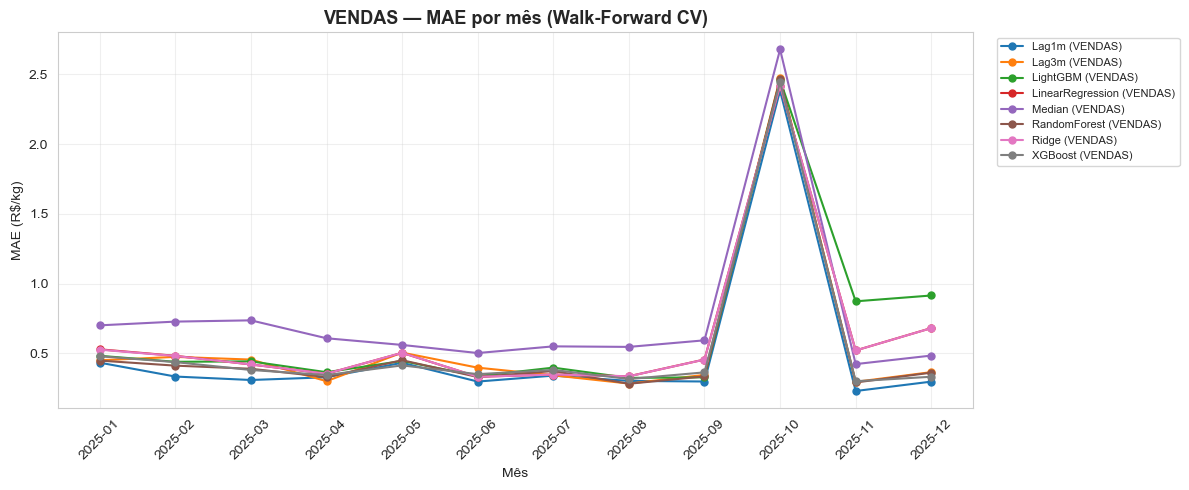


  RESUMO GLOBAL


,model,side,n_folds,n_total,MAE_mean,MAE_std,RMSE_mean,R2_mean,MAPE_%_mean
0,Lag1m (VENDAS),VENDAS,12,1452,0.4998,0.5961,2.7042,0.8541,6.4
5,RandomForest (VENDAS),VENDAS,12,1452,0.5400,0.6091,2.6852,0.8588,9.8
7,XGBoost (VENDAS),VENDAS,12,1452,0.5463,0.6001,2.7066,0.8559,10.4
1,Lag3m (VENDAS),VENDAS,12,1452,0.5583,0.6076,2.7986,0.8347,8.6
6,Ridge (VENDAS),VENDAS,12,1452,0.6157,0.5771,2.8374,0.8030,13.7
3,LinearRegression (VENDAS),VENDAS,12,1452,0.6161,0.5770,2.8377,0.8030,13.7
2,LightGBM (VENDAS),VENDAS,12,1452,0.6516,0.6032,2.9987,0.7107,12.1
4,Median (VENDAS),VENDAS,12,1420,0.7601,0.6120,3.0596,0.7767,17.9



Melhor modelo VENDAS: Lag1m (VENDAS) — MAE = 0.4998 ± 0.5961


In [246]:
# ── CV Results: per-month and global summary ──

side = "VENDAS"
side_scores = df_cv_scores[df_cv_scores["side"] == side].copy()
if not side_scores.empty:
    print(f"\n{'='*65}")
    print(f"  {side} — Métricas por mês")
    print(f"{'='*65}")

    pivot_mae = side_scores.pivot(index="month", columns="model", values="MAE")
    pivot_mae = pivot_mae[[c for c in sorted(pivot_mae.columns)]]
    display(pivot_mae.round(4))

    fig, ax = plt.subplots(figsize=(12, 5))
    for col in pivot_mae.columns:
        ax.plot(pivot_mae.index, pivot_mae[col], "o-", label=col, linewidth=1.5, markersize=5)
    ax.set_title(f"{side} — MAE por mês (Walk-Forward CV)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Mês")
    ax.set_ylabel("MAE (R$/kg)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Global summary
print(f"\n{'='*65}")
print(f"  RESUMO GLOBAL")
print(f"{'='*65}")

all_results = []
for (model_name, side_name), grp in df_cv_scores.groupby(["model", "side"]):
    all_results.append({
        "model": model_name,
        "side": side_name,
        "n_folds": len(grp),
        "n_total": grp["n"].sum(),
        "MAE_mean": round(grp["MAE"].mean(), 4),
        "MAE_std": round(grp["MAE"].std(), 4),
        "RMSE_mean": round(grp["RMSE"].mean(), 4),
        "R2_mean": round(grp["R2"].mean(), 4),
        "MAPE_%_mean": round(grp["MAPE_%"].mean(), 1),
    })

df_all_results = pd.DataFrame(all_results).sort_values(["side", "MAE_mean"])
display(df_all_results)

best_models = {}
side_df = df_all_results[df_all_results["side"] == "VENDAS"]
if not side_df.empty:
    best_row = side_df.iloc[0]
    best_models["VENDAS"] = best_row["model"]
    print(f"\nMelhor modelo VENDAS: {best_row['model']} — MAE = {best_row['MAE_mean']:.4f} ± {best_row['MAE_std']:.4f}")

## 8b. Acurácia por Estado e Estado × Cluster


  VENDAS — MAE por Estado (best: Lag1m)


,state,n_obs,MAE_Lag1m,MAE_Median,MAE_Lag3m,MAE_LinearRegression,MAE_Ridge,MAE_RandomForest,MAE_XGBoost,MAE_LightGBM
0,AL,4,0.0000,0.0000,0.0000,0.1399,0.1387,0.0036,0.0528,0.0228
10,MT,1,0.0000,0.0600,0.0600,0.2255,0.2213,0.0396,0.0567,0.0301
20,SE,2,0.0250,0.0000,0.0250,0.2963,0.2939,0.0362,0.0185,0.3414
1,AM,7,0.0268,0.0575,0.0482,0.1908,0.1908,0.1710,0.1179,0.2819
14,PI,2,0.0350,0.0700,0.0700,0.1157,0.1168,0.1203,0.1135,0.1350
7,MA,55,0.1368,0.2029,0.1552,0.2565,0.2559,0.1532,0.1799,0.3227
15,PR,215,0.1867,0.4447,0.2000,0.2545,0.2543,0.2148,0.2190,0.2348
13,PE,30,0.2212,0.8944,0.3078,0.6518,0.6526,0.2658,0.3117,0.3302
4,DF,52,0.2491,0.4351,0.3153,0.3329,0.3324,0.2605,0.2606,0.2919
18,RS,186,0.2716,0.5051,0.2854,0.3440,0.3434,0.3102,0.3253,0.4874


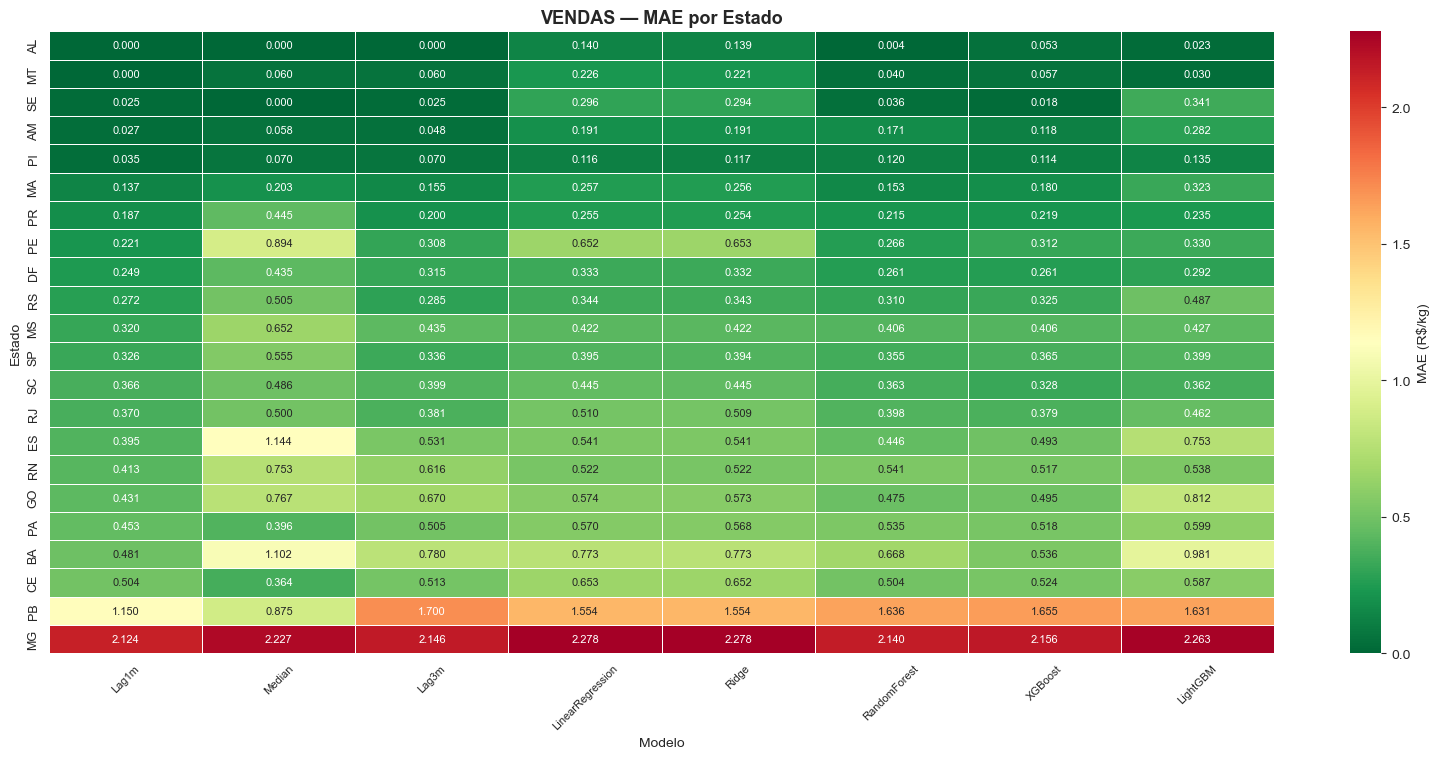


  VENDAS — MAE por Estado × material_cluster (best: Lag1m)


,state,material_cluster,n_obs,MAE_Lag1m,MAE_Lag3m,MAE_Median
0,AL,OUTROS::SUCATA DE PLASTICO,4,0.0000,0.0000,0.0000
80,MG,PS::PS COPINHO,3,0.0000,0.0667,0.0333
83,MS,OUTROS::PLASTICOS DIVERSOS,3,0.0000,0.0000,0.0000
63,MG,BOPP/RAFIA::SUCATA DE RAFIA,8,0.0000,0.0000,0.0000
91,MT,OUTROS::SUCATA DE PLASTICO,1,0.0000,0.0600,0.0600
...,...,...,...,...,...,...
167,SC,PEAD::SUCATA DE PEAD COLORIDO,2,2.0000,2.8000,2.8000
169,SC,PP::PP BRANCO,1,2.2000,2.2000,2.2000
46,GO,OUTROS::SUCATA DE LATINHAS,6,2.4075,3.8342,3.2617
95,PA,PET::SUCATA DE PET VERDE,2,2.6200,1.7775,1.8700


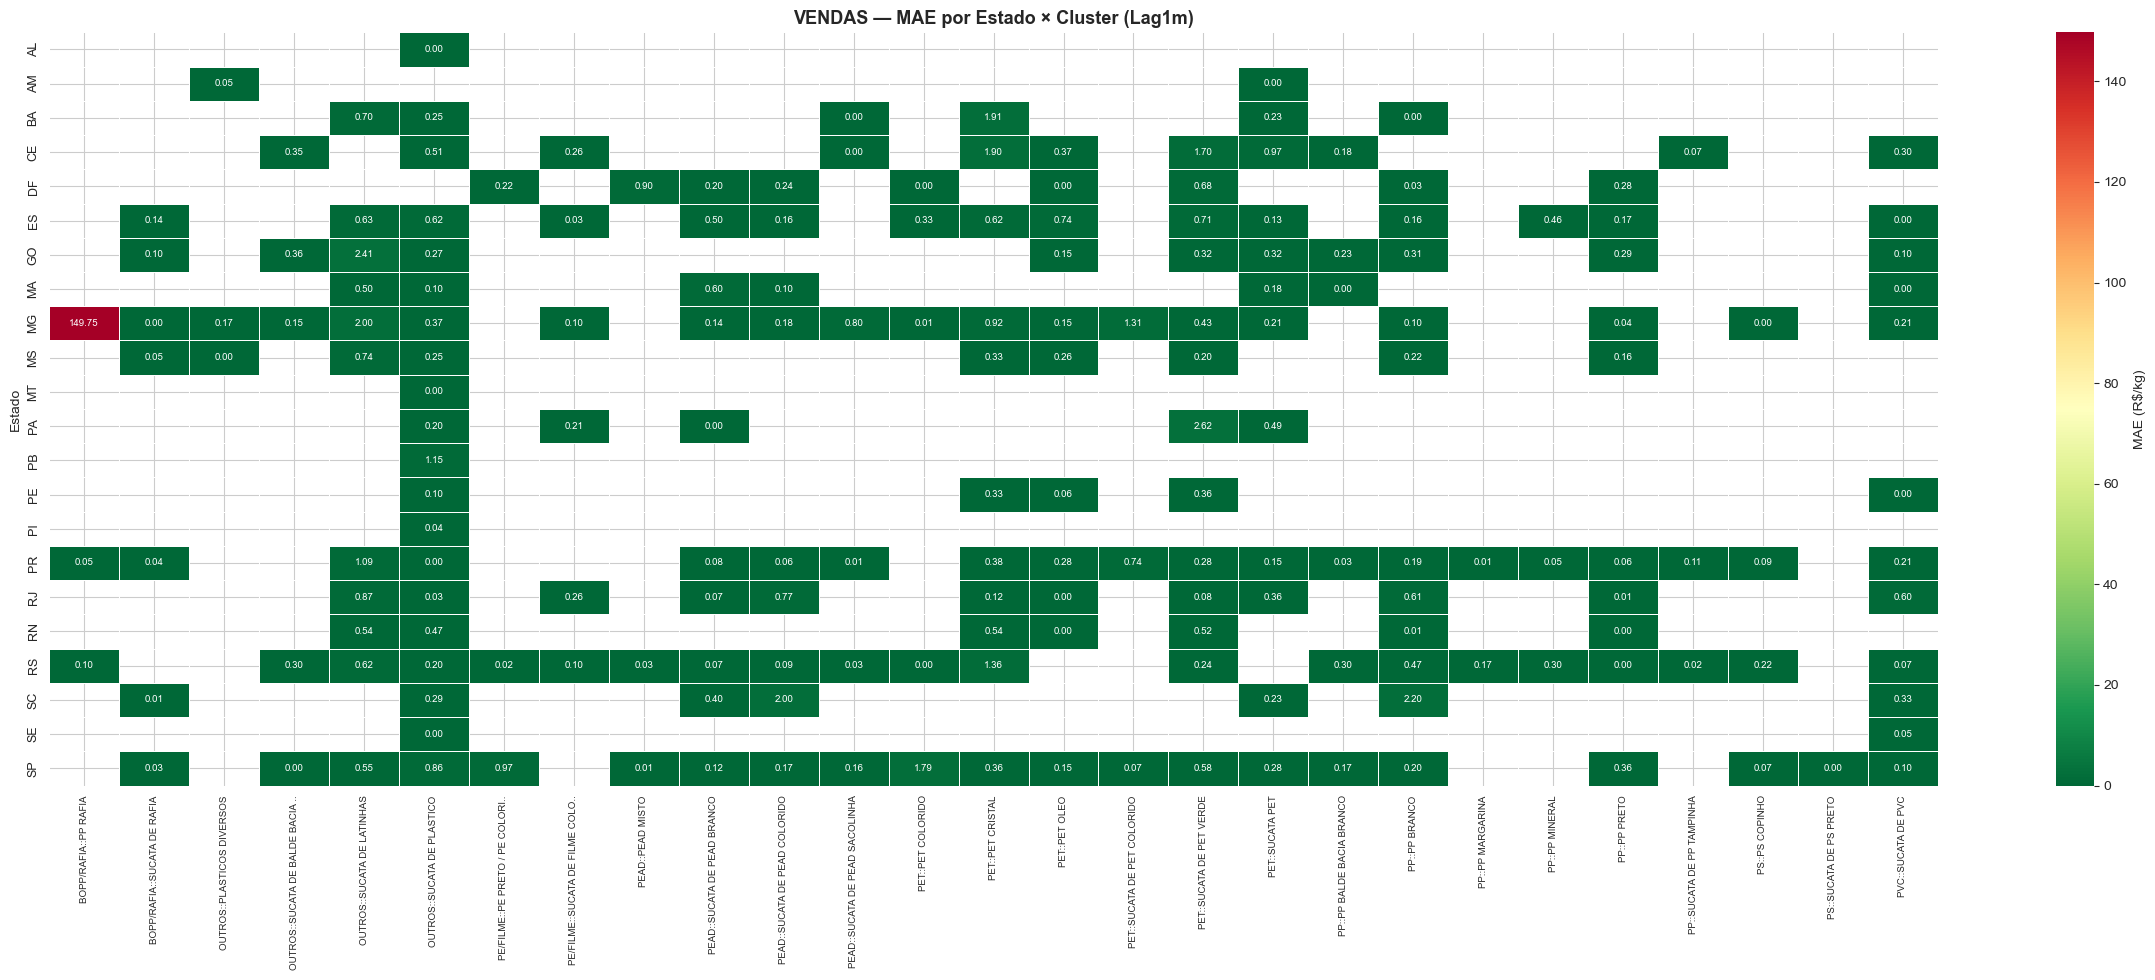


  Top 10 MENOR MAE (Lag1m):


,state,material_cluster,n_obs,MAE_Lag1m
0,AL,OUTROS::SUCATA DE PLASTICO,4,0.0
80,MG,PS::PS COPINHO,3,0.0
83,MS,OUTROS::PLASTICOS DIVERSOS,3,0.0
63,MG,BOPP/RAFIA::SUCATA DE RAFIA,8,0.0
91,MT,OUTROS::SUCATA DE PLASTICO,1,0.0
61,MA,PVC::SUCATA DE PVC,9,0.0
60,MA,PP::PP BALDE BACIA BRANCO,10,0.0
94,PA,PEAD::SUCATA DE PEAD BRANCO,3,0.0
192,SP,PS::SUCATA DE PS PRETO,2,0.0
102,PE,PVC::SUCATA DE PVC,6,0.0



  Top 10 MAIOR MAE (Lag1m):


,state,material_cluster,n_obs,MAE_Lag1m
15,CE,PET::SUCATA DE PET VERDE,1,1.7000
182,SP,PET::PET COLORIDO,6,1.7917
13,CE,PET::PET CRISTAL,1,1.9000
6,BA,PET::PET CRISTAL,3,1.9083
66,MG,OUTROS::SUCATA DE LATINHAS,10,2.0000
167,SC,PEAD::SUCATA DE PEAD COLORIDO,2,2.0000
169,SC,PP::PP BRANCO,1,2.2000
46,GO,OUTROS::SUCATA DE LATINHAS,6,2.4075
95,PA,PET::SUCATA DE PET VERDE,2,2.6200
62,MG,BOPP/RAFIA::PP RAFIA,2,149.7500


In [247]:
pred_cols = [c for c in test.columns if c.startswith("pred_")]
model_names_eval = [c.replace("pred_", "") for c in pred_cols]

side = "VENDAS"
te = test[test["side"] == side].copy()

best_model_name = best_models.get(side)
if best_model_name is not None:
    best_short = best_model_name.replace(f" ({side})", "")
    best_pred_col = f"pred_{best_short}"

    if best_pred_col in te.columns:
        compare_models = [best_short] + [m for m in model_names_eval if m != best_short]

        # 1) MAE by STATE
        print(f"\n{'='*65}")
        print(f"  {side} — MAE por Estado (best: {best_short})")
        print(f"{'='*65}")

        state_metrics = []
        for state, grp_df in te.groupby("emitterstateuf"):
            row = {"state": state, "n_obs": len(grp_df)}
            for mname in compare_models:
                col = f"pred_{mname}"
                if col in grp_df.columns:
                    valid = grp_df.dropna(subset=[col])
                    if len(valid) > 0:
                        row[f"MAE_{mname}"] = round(mean_absolute_error(valid[TARGET], valid[col]), 4)
                    else:
                        row[f"MAE_{mname}"] = np.nan
            state_metrics.append(row)

        df_state = pd.DataFrame(state_metrics).sort_values(f"MAE_{best_short}")
        display(df_state)

        mae_cols = [c for c in df_state.columns if c.startswith("MAE_")]
        if len(mae_cols) > 0 and len(df_state) >= 3:
            fig, ax = plt.subplots(figsize=(max(10, len(mae_cols) * 2), max(5, len(df_state) * 0.35)))
            hm_data = df_state.set_index("state")[mae_cols].rename(columns=lambda c: c.replace("MAE_", ""))
            sns.heatmap(hm_data, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=ax,
                        linewidths=0.5, cbar_kws={"label": "MAE (R$/kg)"},
                        annot_kws={"fontsize": 8})
            ax.set_title(f"{side} — MAE por Estado", fontsize=13, fontweight="bold")
            ax.set_ylabel("Estado", fontsize=10)
            ax.set_xlabel("Modelo", fontsize=10)
            ax.tick_params(axis="x", labelsize=8, rotation=45)
            ax.tick_params(axis="y", labelsize=9)
            plt.tight_layout()
            plt.show()

        # 2) MAE by STATE × CLUSTER
        print(f"\n{'='*65}")
        print(f"  {side} — MAE por Estado × {group_key} (best: {best_short})")
        print(f"{'='*65}")

        pair_metrics = []
        for (state, grp_name), grp_df in te.groupby(["emitterstateuf", group_key]):
            row = {"state": state, group_key: grp_name, "n_obs": len(grp_df)}
            for mname in [best_short, "Lag3m", "Median"]:
                col = f"pred_{mname}"
                if col in grp_df.columns:
                    valid = grp_df.dropna(subset=[col])
                    if len(valid) > 0:
                        row[f"MAE_{mname}"] = round(mean_absolute_error(valid[TARGET], valid[col]), 4)
                    else:
                        row[f"MAE_{mname}"] = np.nan
            pair_metrics.append(row)

        df_pairs = pd.DataFrame(pair_metrics).sort_values(f"MAE_{best_short}")
        display(df_pairs)

        cluster_vals = sorted(te[group_key].unique())
        pivot_pairs = df_pairs.pivot(index="state", columns=group_key, values=f"MAE_{best_short}")
        pivot_pairs = pivot_pairs[[g for g in cluster_vals if g in pivot_pairs.columns]]
        # Truncate long cluster names for readability
        pivot_pairs.columns = [c[:30] + ".." if len(c) > 30 else c for c in pivot_pairs.columns]
        if not pivot_pairs.empty:
            n_cols = len(pivot_pairs.columns)
            n_rows = len(pivot_pairs)
            fig, ax = plt.subplots(figsize=(max(14, n_cols * 0.9), max(5, n_rows * 0.45)))
            sns.heatmap(pivot_pairs, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax,
                        linewidths=0.5, cbar_kws={"label": "MAE (R$/kg)"},
                        annot_kws={"fontsize": 7})
            ax.set_title(f"{side} — MAE por Estado × Cluster ({best_short})", fontsize=13, fontweight="bold")
            ax.set_ylabel("Estado", fontsize=10)
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=7, rotation=90)
            ax.tick_params(axis="y", labelsize=9)
            plt.tight_layout()
            plt.show()

        # Top/bottom pairs
        valid_pairs = df_pairs.dropna(subset=[f"MAE_{best_short}"])
        if len(valid_pairs) >= 5:
            print(f"\n  Top 10 MENOR MAE ({best_short}):")
            display(valid_pairs.head(10)[["state", group_key, "n_obs", f"MAE_{best_short}"]])
            print(f"\n  Top 10 MAIOR MAE ({best_short}):")
            display(valid_pairs.tail(10)[["state", group_key, "n_obs", f"MAE_{best_short}"]])

## 8c. Acurácia por Tier de Qualidade dos Dados

Quality tier distribution in test set:


quality
A (excellent)       591
B (good)            522
C (fair)            252
D (insufficient)     87
Name: count, dtype: int64


  VENDAS — MAE por Tier de Qualidade


,quality_tier,n_obs,MAE_Median,MAE_Lag1m,MAE_Lag3m,MAE_LinearRegression,MAE_Ridge,MAE_RandomForest,MAE_XGBoost,MAE_LightGBM
0,A (excellent),591,0.5944,0.2941,0.3078,0.3967,0.3963,0.3332,0.3437,0.4325
1,B (good),522,0.6250,0.3395,0.4442,0.4675,0.4671,0.3838,0.3974,0.4858
2,C (fair),252,0.4856,0.3448,0.4125,0.4324,0.4318,0.3900,0.3759,0.5178
3,D (insufficient),87,5.1800,3.7432,3.7965,3.9753,3.9750,3.7602,3.7566,3.9889


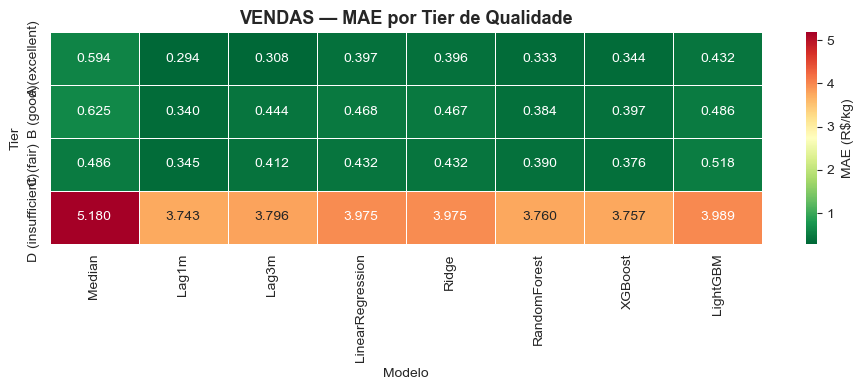

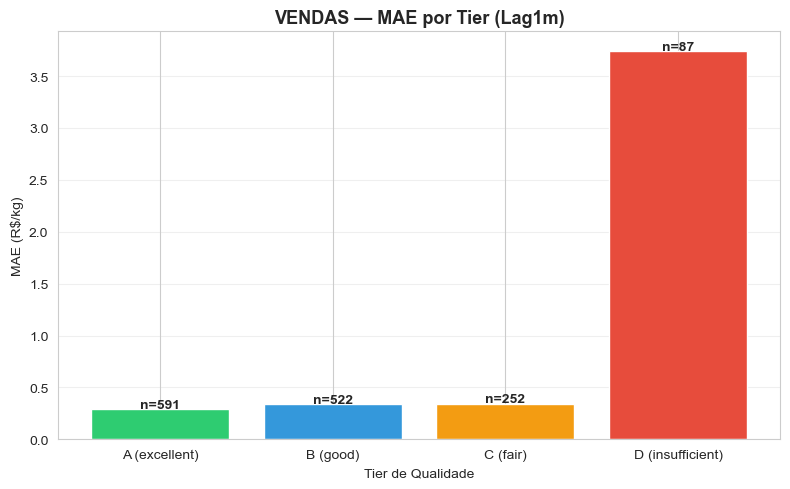

In [248]:
coverage_opt = (
    df_price_clean.groupby([group_key, "emitterstateuf"])
    .agg(n_rows=(PRICE_COL, "count"), n_months=("year_month", "nunique"))
    .reset_index()
)
coverage_opt["quality"] = coverage_opt.apply(quality_tier, axis=1)

# test already has "quality" from monthly_feat (cell 23), use it directly
test_qt = test.copy()
if "quality" not in test_qt.columns:
    test_qt = test_qt.merge(
        coverage_opt[[group_key, "emitterstateuf", "quality"]],
        on=[group_key, "emitterstateuf"], how="left"
    )
test_qt["quality"] = test_qt["quality"].fillna("D (insufficient)")

print(f"Quality tier distribution in test set:")
display(test_qt["quality"].value_counts().sort_index())

pred_cols_qt = [c for c in test_qt.columns if c.startswith("pred_")]
model_names_qt = [c.replace("pred_", "") for c in pred_cols_qt]

te = test_qt[test_qt["side"] == "VENDAS"].copy()
if len(te) > 0:
    print(f"\n{'='*65}")
    print(f"  VENDAS — MAE por Tier de Qualidade")
    print(f"{'='*65}")

    tier_metrics = []
    for tier, grp_df in te.groupby("quality"):
        row = {"quality_tier": tier, "n_obs": len(grp_df)}
        for mname in model_names_qt:
            col = f"pred_{mname}"
            if col in grp_df.columns:
                valid = grp_df.dropna(subset=[col])
                if len(valid) > 0:
                    row[f"MAE_{mname}"] = round(mean_absolute_error(valid[TARGET], valid[col]), 4)
                else:
                    row[f"MAE_{mname}"] = np.nan
        tier_metrics.append(row)

    df_tier = pd.DataFrame(tier_metrics).sort_values("quality_tier")
    display(df_tier)

    mae_cols_t = [c for c in df_tier.columns if c.startswith("MAE_")]
    if len(mae_cols_t) > 0 and len(df_tier) >= 2:
        fig, ax = plt.subplots(figsize=(max(8, len(mae_cols_t) * 1.2), 4))
        hm_data = df_tier.set_index("quality_tier")[mae_cols_t].rename(columns=lambda c: c.replace("MAE_", ""))
        sns.heatmap(hm_data, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=ax,
                    linewidths=0.5, cbar_kws={"label": "MAE (R$/kg)"})
        ax.set_title(f"VENDAS — MAE por Tier de Qualidade", fontsize=13, fontweight="bold")
        ax.set_ylabel("Tier")
        ax.set_xlabel("Modelo")
        plt.tight_layout()
        plt.show()

    # Bar chart for best model
    best_model_name = best_models.get("VENDAS")
    if best_model_name:
        best_short = best_model_name.replace(" (VENDAS)", "")
        best_col = f"MAE_{best_short}"
        if best_col in df_tier.columns:
            fig, ax = plt.subplots(figsize=(8, 5))
            colors = {"A (excellent)": "#2ecc71", "B (good)": "#3498db",
                      "C (fair)": "#f39c12", "D (insufficient)": "#e74c3c"}
            bars = df_tier.dropna(subset=[best_col])
            bar_colors = [colors.get(t, "gray") for t in bars["quality_tier"]]
            ax.bar(bars["quality_tier"], bars[best_col], color=bar_colors, edgecolor="white")
            for i, (tier, val, n) in enumerate(zip(bars["quality_tier"], bars[best_col], bars["n_obs"])):
                ax.text(i, val + 0.01, f"n={n}", ha="center", fontsize=10, fontweight="bold")
            ax.set_title(f"VENDAS — MAE por Tier ({best_short})", fontsize=13, fontweight="bold")
            ax.set_ylabel("MAE (R$/kg)")
            ax.set_xlabel("Tier de Qualidade")
            ax.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()

## 8d. Acurácia por Setor CNAE


  VENDAS — MAE por Setor CNAE (best: Lag1m)


,sector,n_obs,MAE_Lag1m,MAE_Lag3m,MAE_Median
4,OUTROS_SETOR,16,0.1969,0.2781,0.2719
0,COLETA_RECICLAGEM,614,0.3182,0.3737,0.5757
1,COMERCIO_ATACADO,244,0.4169,0.5234,0.9019
2,COOPERATIVA,574,0.7942,0.8252,0.9665
3,INDUSTRIA,4,1.8563,3.1937,0.7687


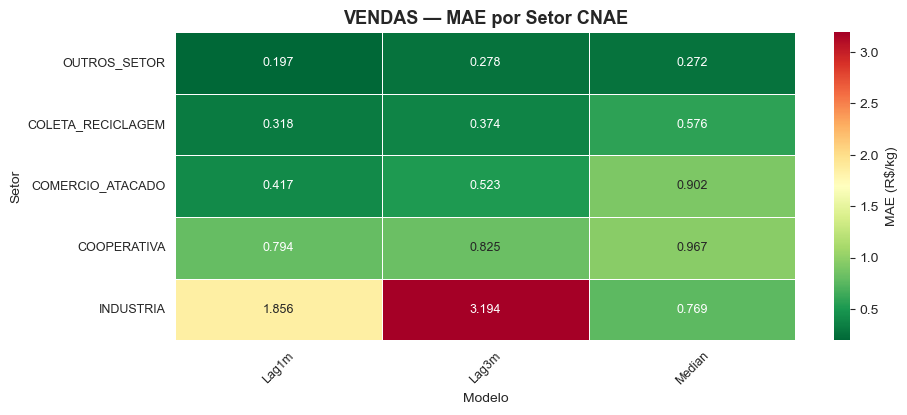

<Figure size 640x480 with 0 Axes>

In [249]:
# ── MAE breakdown by dominant sector ──

te = test.copy()

# Merge dominant sector into test predictions
if 'dominant_sector' in te.columns:
    te = te.drop(columns=['dominant_sector'])
sd_test = df_price_clean.groupby([group_key, 'emitterstateuf'])['emitter_sector'].agg(
    lambda x: x.value_counts().index[0]).reset_index().rename(columns={'emitter_sector': 'dominant_sector'})
te = te.merge(sd_test, on=[group_key, 'emitterstateuf'], how='left')
te['dominant_sector'] = te['dominant_sector'].fillna('DESCONHECIDO')

side = "VENDAS"
te_v = te[te["side"] == side].copy()

best_model_name = best_models.get(side)
if best_model_name and len(te_v) > 0:
    best_short = best_model_name.replace(f" ({side})", "")

    print(f"\n{'='*65}")
    print(f"  {side} — MAE por Setor CNAE (best: {best_short})")
    print(f"{'='*65}")

    sector_met = []
    for sector, grp_df in te_v.groupby('dominant_sector'):
        row = {'sector': sector, 'n_obs': len(grp_df)}
        for mname in [best_short, 'Lag3m', 'Median']:
            col = f'pred_{mname}'
            if col in grp_df.columns:
                valid = grp_df.dropna(subset=[col])
                if len(valid) > 0:
                    row[f'MAE_{mname}'] = round(mean_absolute_error(valid[TARGET], valid[col]), 4)
                else:
                    row[f'MAE_{mname}'] = np.nan
        sector_met.append(row)

    df_sector = pd.DataFrame(sector_met).sort_values(f'MAE_{best_short}')
    display(df_sector)

    mae_cols_s = [c for c in df_sector.columns if c.startswith('MAE_')]
    if len(mae_cols_s) > 0 and len(df_sector) >= 2:
        fig, ax = plt.subplots(figsize=(max(10, len(mae_cols_s) * 2.5), max(4, len(df_sector) * 0.5)))
        hm_data = df_sector.set_index('sector')[mae_cols_s].rename(columns=lambda c: c.replace('MAE_', ''))
        sns.heatmap(hm_data, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax,
                    linewidths=0.5, cbar_kws={'label': 'MAE (R$/kg)'},
                    annot_kws={'fontsize': 9})
        ax.set_title(f'{side} — MAE por Setor CNAE', fontsize=13, fontweight='bold')
        ax.set_ylabel('Setor', fontsize=10)
        ax.set_xlabel('Modelo', fontsize=10)
        ax.tick_params(axis='x', labelsize=9, rotation=45)

        ax.tick_params(axis='y', labelsize=9)
        plt.show()
        plt.tight_layout()

## 9. Feature Importance

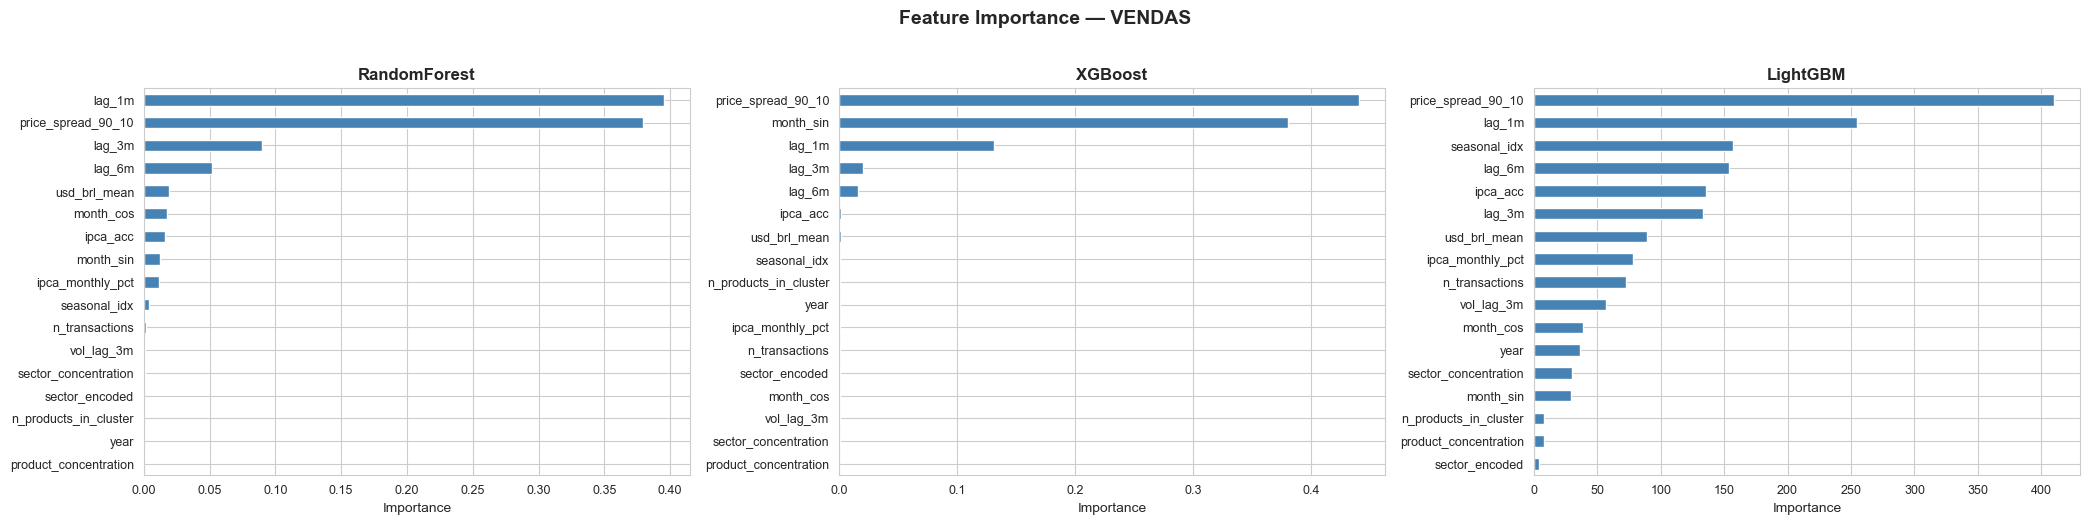

In [250]:
tree_models = [n for n in ["RandomForest", "XGBoost", "LightGBM"]
               if ("VENDAS", n) in trained_models]

if tree_models:
    fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), max(5, len(FEATURES) * 0.3)))
    if len(tree_models) == 1:
        axes = [axes]

    for ax, mname in zip(axes, tree_models):
        imp = trained_models[("VENDAS", mname)].feature_importances_
        feat_imp = pd.Series(imp, index=FEATURES).sort_values(ascending=True)
        feat_imp.plot(kind="barh", ax=ax, color="steelblue")
        ax.set_title(f"{mname}", fontweight="bold", fontsize=12)
        ax.set_xlabel("Importance", fontsize=10)
        ax.tick_params(axis="y", labelsize=9)
        ax.tick_params(axis="x", labelsize=9)

    plt.suptitle("Feature Importance — VENDAS",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

else:    print("No tree-based models were trained.")

## 9b. Diagnóstico de Heterogeneidade vs Performance

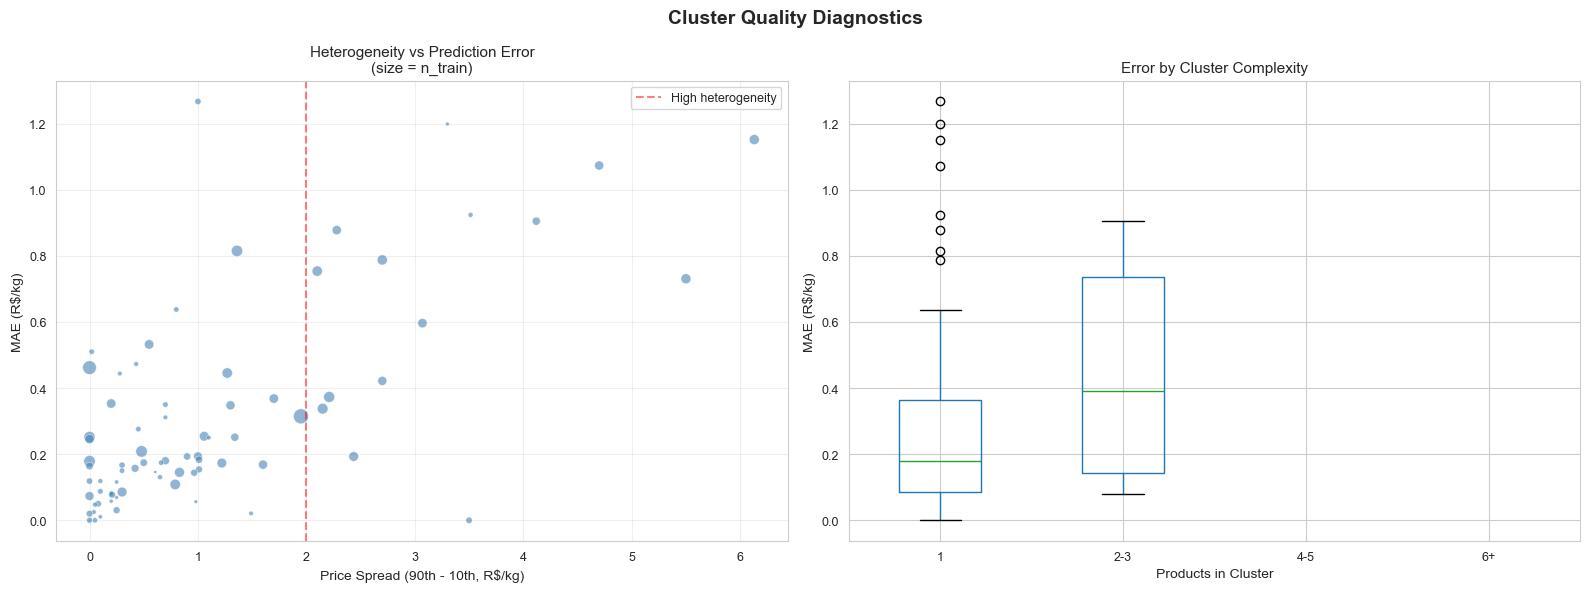


Clusters needing further splitting (10):


,cluster,state,mae,price_spread_90_10,n_products_in_cluster
2,PET::SUCATA DE PET COLORIDO,MG,1.198586,3.300,1
3,OUTROS::SUCATA DE LATINHAS,ES,1.151484,6.130,1
4,OUTROS::SUCATA DE LATINHAS,BA,1.072995,4.700,1
5,PEAD::PEAD MISTO,DF,0.923600,3.514,1
6,PET::PET CRISTAL,ES,0.904548,4.120,2
7,PET::SUCATA PET,GO,0.877500,2.280,1
9,PET::SUCATA PET,MG,0.787500,2.700,1
10,PET::SUCATA DE PET VERDE,GO,0.753611,2.100,2
11,PET::PET CRISTAL,BA,0.730477,5.500,2
13,PET::SUCATA DE PET VERDE,ES,0.596179,3.070,2


In [251]:
if per_cluster_errors:
    cluster_perf = pd.DataFrame(per_cluster_errors)

    poor_clusters = (
        cluster_perf[cluster_perf['model'] == 'Lag3m']
        .groupby(['cluster', 'state'])
        .agg(mae=('mae', 'mean'), n_train=('n_train', 'first'), actual_price=('actual_price', 'mean'))
        .reset_index()
        .sort_values('mae', ascending=False)
    )

    diagnostic = poor_clusters.merge(
        heterogeneity,
        left_on=['cluster', 'state'],
        right_on=[best_cluster_col, 'emitterstateuf'],
        how='left'
    )

    # Remove MAE outliers above 99th percentile
    mae_cap = diagnostic['mae'].quantile(0.99)
    diagnostic = diagnostic[diagnostic['mae'] <= mae_cap].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    valid_diag = diagnostic.dropna(subset=['price_spread_90_10', 'mae'])
    if len(valid_diag) > 0:
        axes[0].scatter(valid_diag['price_spread_90_10'], valid_diag['mae'],
                       s=valid_diag['n_train'].clip(upper=500) / 3, alpha=0.6, c='steelblue', edgecolors='white', linewidth=0.5)
        axes[0].set_xlabel("Price Spread (90th - 10th, R$/kg)", fontsize=10)
        axes[0].set_ylabel("MAE (R$/kg)", fontsize=10)
        axes[0].set_title("Heterogeneity vs Prediction Error\n(size = n_train)", fontsize=11)
        axes[0].axvline(2.0, color='red', linestyle='--', alpha=0.5, label='High heterogeneity')
        axes[0].legend(fontsize=9)
        axes[0].grid(True, alpha=0.3)
        axes[0].tick_params(labelsize=9)

    valid_diag2 = diagnostic.dropna(subset=['n_products_in_cluster', 'mae'])
    if len(valid_diag2) > 0:
        valid_diag2['product_bucket'] = pd.cut(
            valid_diag2['n_products_in_cluster'],
            bins=[0, 1, 3, 5, 100],
            labels=['1', '2-3', '4-5', '6+']
        )
        valid_diag2.boxplot(column='mae', by='product_bucket', ax=axes[1])
        axes[1].set_xlabel("Products in Cluster", fontsize=10)
        axes[1].set_ylabel("MAE (R$/kg)", fontsize=10)
        axes[1].set_title("Error by Cluster Complexity", fontsize=11)
        axes[1].tick_params(labelsize=9)
        plt.suptitle("")

    plt.suptitle(f"Cluster Quality Diagnostics", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    high_error_het = diagnostic[
        (diagnostic['mae'] > diagnostic['mae'].quantile(0.8)) &
        (diagnostic['price_spread_90_10'] > 2.0)
    ]
    if len(high_error_het) > 0:
        print(f"\nClusters needing further splitting ({len(high_error_het)}):")
        display(high_error_het[['cluster', 'state', 'mae', 'price_spread_90_10',
                                 'n_products_in_cluster']].sort_values('mae', ascending=False))
    else:
        print("\nNo clusters with both high error and high heterogeneity.")
else:
    print("No per-cluster error data available.")

In [252]:
# ── Clusters with 2-3 products: detail materials and their counts ──

clusters_2_3 = heterogeneity[
    (heterogeneity['n_products_in_cluster'] >= 2) &
    (heterogeneity['n_products_in_cluster'] <= 3)
][best_cluster_col].unique()

print(f"Clusters with 2-3 products: {len(clusters_2_3)}\n")
print("=" * 90)

for cluster_name in sorted(clusters_2_3):
    cluster_data = df_price_clean[df_price_clean[best_cluster_col] == cluster_name]
    product_counts = (
        cluster_data.groupby('estoque_product')
        .agg(
            n_registers=(PRICE_COL, 'count'),
            median_price=(PRICE_COL, 'median'),
            cv=(PRICE_COL, lambda x: round(x.std() / x.mean(), 3) if x.mean() > 0 else 0),
        )
        .sort_values('n_registers', ascending=False)
        .reset_index()
    )
    states = cluster_data['emitterstateuf'].nunique()
    print(f"\n📦 {cluster_name}  ({len(cluster_data):,} registros, {states} estados)")
    print(f"   {'Produto':<45s} {'N':>7s} {'Mediana':>9s} {'CV':>6s}")
    print(f"   {'─'*70}")
    for _, row in product_counts.iterrows():
        print(f"   {row['estoque_product'][:45]:<45s} {row['n_registers']:>7,} {row['median_price']:>8.2f} {row['cv']:>6.3f}")

print(f"\n{'='*90}")

Clusters with 2-3 products: 5


📦 PET::PET CRISTAL  (1,929 registros, 15 estados)
   Produto                                             N   Mediana     CV
   ──────────────────────────────────────────────────────────────────────
   PET CRISTAL                                     1,232     4.00  0.471
   SUCATA DE PET CRISTAL                             697     5.00  0.252

📦 PET::SUCATA DE PET VERDE  (1,851 registros, 19 estados)
   Produto                                             N   Mediana     CV
   ──────────────────────────────────────────────────────────────────────
   SUCATA DE PET VERDE                             1,180     4.80  0.291
   PET VERDE                                         671     3.75  0.339

📦 PP::PP BALDE BACIA BRANCO  (524 registros, 10 estados)
   Produto                                             N   Mediana     CV
   ──────────────────────────────────────────────────────────────────────
   PP BALDE BACIA BRANCO                             330     1.00

## 10. Tabela de Preço Justo


  TABELA DE PREÇO JUSTO (R$/kg) — VENDAS (material_cluster)
  199 pares totais → 144 após remoção de D (insufficient)

Quality distribution:


quality
A (excellent)    36
B (good)         37
C (fair)         71
Name: count, dtype: int64

,cluster,material_base,state,dominant_sector,n_obs,median_price,Q1,Q3,fair_buy,fair_sell,fair_target,heterogeneity,n_products,n_months_data,top_products,quality
0,BOPP/RAFIA::PP RAFIA,BOPP/RAFIA,PR,COOPERATIVA,129,0.300,0.200,0.400,0.200,0.400,0.300,0.337,1,35,PP RAFIA,B (good)
2,BOPP/RAFIA::SUCATA DE RAFIA,BOPP/RAFIA,PR,COOPERATIVA,56,0.300,0.200,0.362,0.200,0.362,0.300,0.332,1,27,SUCATA DE RAFIA,B (good)
4,BOPP/RAFIA::SUCATA DE RAFIA,BOPP/RAFIA,SC,COOPERATIVA,136,0.650,0.500,0.650,0.500,0.650,0.650,0.130,1,32,SUCATA DE RAFIA,A (excellent)
5,BOPP/RAFIA::SUCATA DE RAFIA,BOPP/RAFIA,SP,COMERCIO_ATACADO,65,0.300,0.100,0.300,0.100,0.300,0.300,0.479,1,25,SUCATA DE RAFIA,B (good)
7,OUTROS::PLASTICOS DIVERSOS,OUTROS,MG,COLETA_RECICLAGEM,48,0.933,0.798,1.135,0.798,1.135,0.933,0.238,1,15,PLASTICOS DIVERSOS,C (fair)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,PVC::SUCATA DE PVC,PVC,CE,COOPERATIVA,20,0.600,0.300,1.300,0.300,1.300,0.600,0.646,1,6,SUCATA DE PVC,C (fair)
192,PVC::SUCATA DE PVC,PVC,MG,COOPERATIVA,51,0.500,0.300,0.550,0.300,0.550,0.500,0.496,1,24,SUCATA DE PVC,B (good)
194,PVC::SUCATA DE PVC,PVC,PR,COLETA_RECICLAGEM,190,0.575,0.450,0.900,0.450,0.900,0.575,0.490,1,36,SUCATA DE PVC,B (good)
196,PVC::SUCATA DE PVC,PVC,RS,COLETA_RECICLAGEM,36,0.400,0.300,0.750,0.300,0.750,0.400,0.532,1,19,SUCATA DE PVC,C (fair)


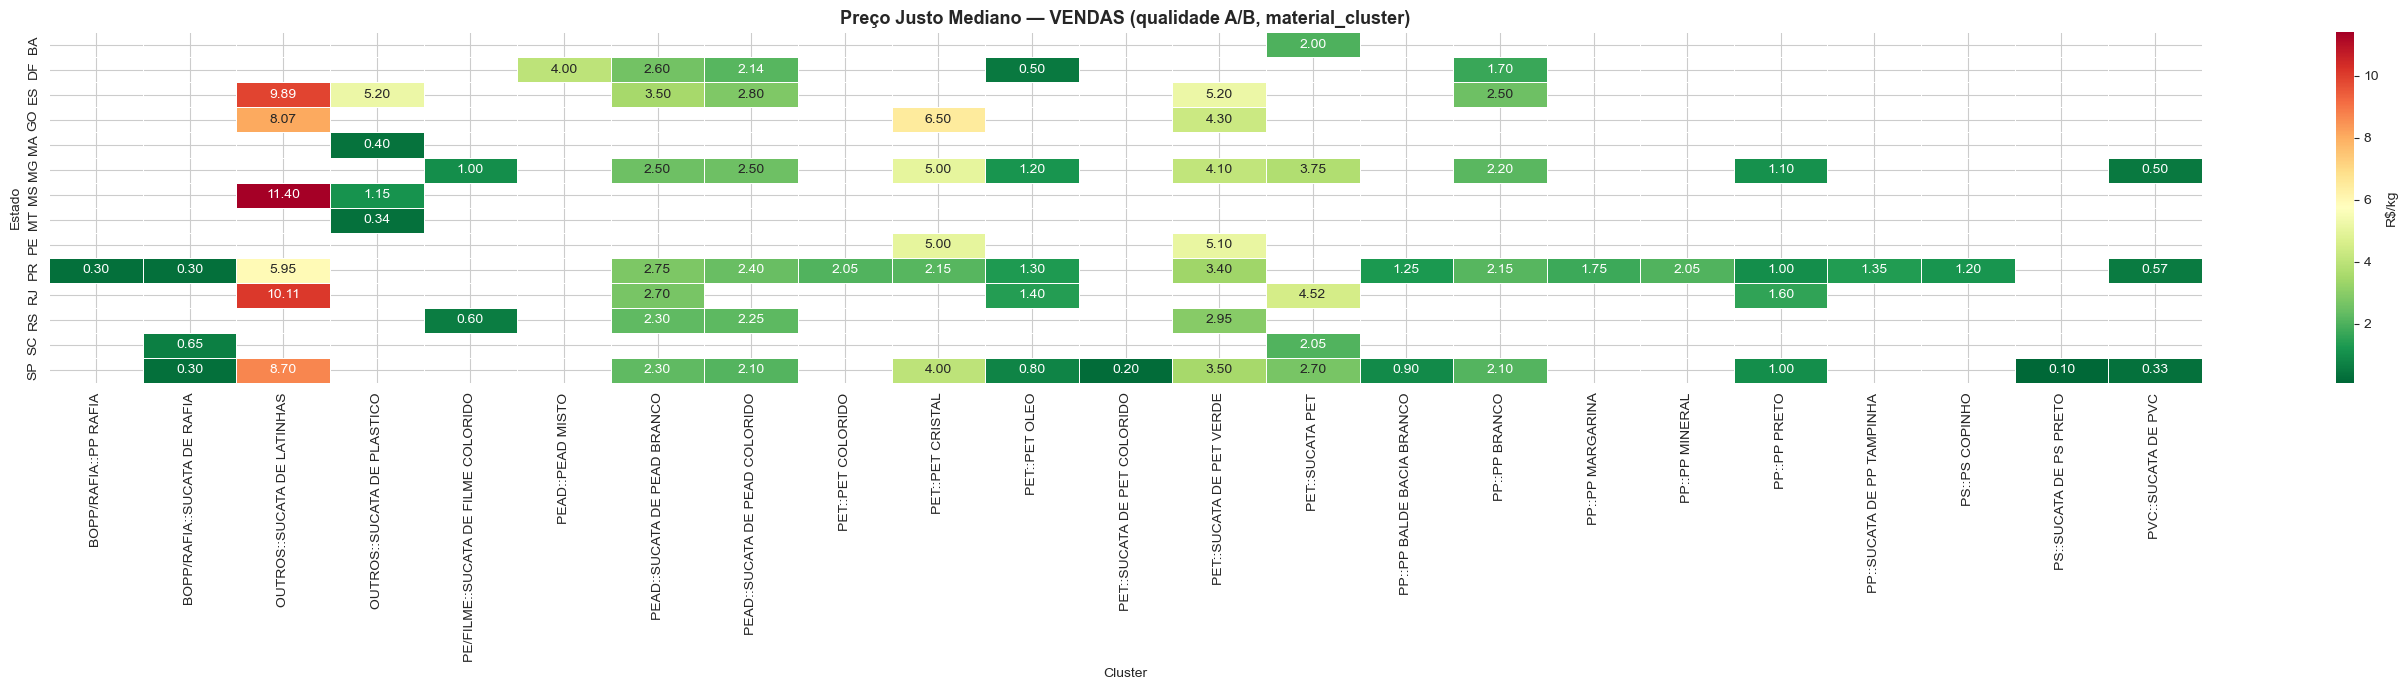

In [253]:
fair_prices = []

side_data = df_price_clean.copy()

for (cluster, state), sub in side_data.groupby([best_cluster_col, "emitterstateuf"]):
    if len(sub) < 5:
        continue

    q1, median, q3 = sub[PRICE_COL].quantile([0.25, 0.5, 0.75])

    # Get dominant sector for this cluster×state
    sector_vc = sub['emitter_sector'].value_counts()
    dom_sector = sector_vc.index[0] if len(sector_vc) > 0 else 'DESCONHECIDO'

    fair_prices.append({
        "cluster": cluster,
        "material_base": sub["material_group"].iloc[0],
        "state": state,
        "dominant_sector": dom_sector,
        "n_obs": len(sub),
        "median_price": round(median, 3),
        "Q1": round(q1, 3),
        "Q3": round(q3, 3),
        "fair_buy": round(q1, 3),
        "fair_sell": round(q3, 3),
        "fair_target": round(median, 3),
        "heterogeneity": round(sub[PRICE_COL].std() / sub[PRICE_COL].mean(), 3) if sub[PRICE_COL].mean() > 0 else 0,
        "n_products": sub["estoque_product"].nunique(),
        "n_months_data": sub["year_month"].nunique(),
        "top_products": ", ".join(sub["estoque_product"].value_counts().head(3).index.tolist()),
    })

df_fair = pd.DataFrame(fair_prices)

def quality_tier_advanced(row):
    if row["n_obs"] >= 100 and row["heterogeneity"] < 0.3:
        return "A (excellent)"
    elif row["n_obs"] >= 50 and row["heterogeneity"] < 0.5:
        return "B (good)"
    elif row["n_obs"] >= 20:
        return "C (fair)"
    else:
        return "D (insufficient)"

df_fair["quality"] = df_fair.apply(quality_tier_advanced, axis=1)

# Remove D (insufficient) from fair price table
n_fair_before = len(df_fair)
df_fair = df_fair[df_fair["quality"] != "D (insufficient)"].copy()

print(f"\n{'='*70}")
print(f"  TABELA DE PREÇO JUSTO (R$/kg) — VENDAS ({best_cluster_col})")
print(f"{'='*70}")
print(f"  {n_fair_before} pares totais → {len(df_fair)} após remoção de D (insufficient)")
print(f"\nQuality distribution:")
display(df_fair["quality"].value_counts().sort_index())
display(df_fair.sort_values(["material_base", "cluster", "state"]))

# Heatmap A/B quality
side_df_ab = df_fair[df_fair["quality"].isin(["A (excellent)", "B (good)"])]
if not side_df_ab.empty:
    pivot = side_df_ab.pivot_table(index="state", columns="cluster", values="median_price", aggfunc="mean")
    if not pivot.empty:
        fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns) * 1.2), max(4, len(pivot) * 0.5)))
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax,
                    linewidths=0.5, cbar_kws={"label": "R$/kg"})
        ax.set_title(f"Preço Justo Mediano — VENDAS (qualidade A/B, {best_cluster_col})",
                     fontsize=13, fontweight="bold")
        ax.set_ylabel("Estado")
        ax.set_xlabel("Cluster")
        plt.tight_layout()
        plt.show()

## 11. Previsão vs Real (2025)

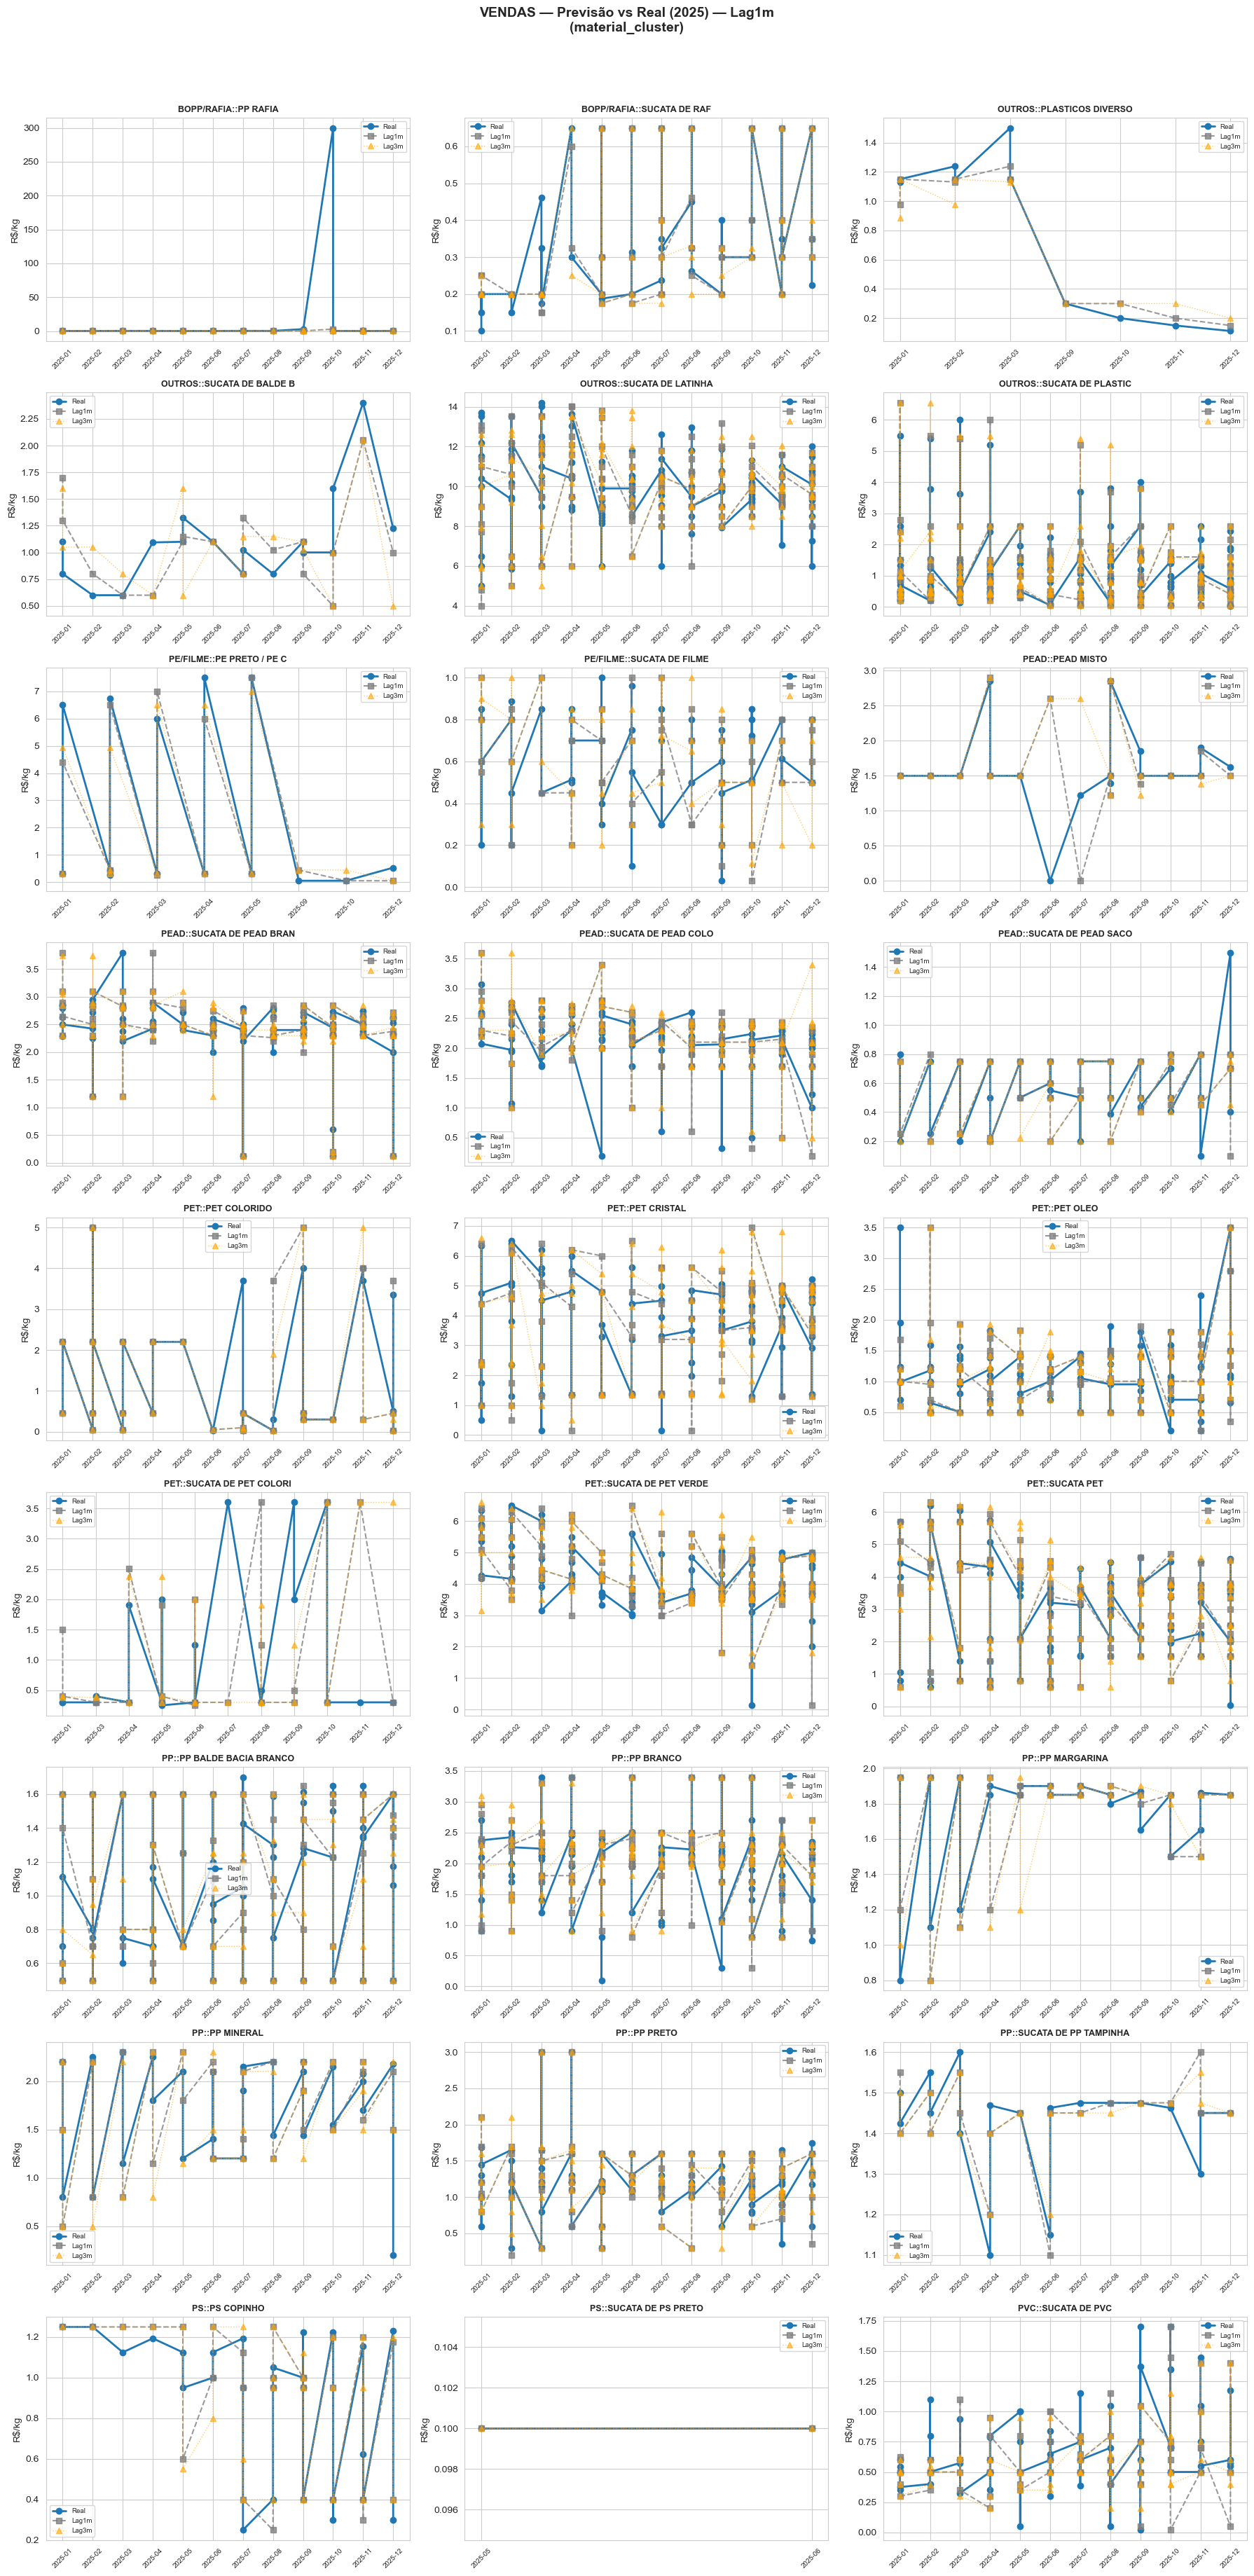

In [254]:
ml_pred_cols = [c for c in test.columns if c.startswith("pred_") and c not in ("pred_Median", "pred_Lag3m")]

side = "VENDAS"
te = test[test["side"] == side].copy()

if len(te) > 0:
    best_col = None
    best_mae = np.inf
    for col in ml_pred_cols:
        valid = te.dropna(subset=[col])
        if len(valid) > 0:
            mae = mean_absolute_error(valid[TARGET], valid[col])
            if mae < best_mae:
                best_mae = mae
                best_col = col

    if best_col is None:
        best_col = "pred_Lag3m"

    model_label = best_col.replace("pred_", "")

    side_groups = sorted(te[group_key].unique())
    if side_groups:
        n = len(side_groups)
        ncols = min(3, n)
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
        axes_flat = np.array(axes).flatten() if n > 1 else [axes]

        for idx, grp in enumerate(side_groups):
            ax = axes_flat[idx]
            grp_data = te[te[group_key] == grp].sort_values("date")
            if len(grp_data) == 0:
                ax.axis("off")
                continue

            x_labels = grp_data["date"].dt.strftime("%Y-%m")
            ax.plot(x_labels, grp_data[TARGET], "o-", label="Real", linewidth=2)
            ax.plot(x_labels, grp_data[best_col], "s--", label=model_label, color="gray", linewidth=1.5, alpha=0.8)
            ax.plot(x_labels, grp_data["pred_Lag3m"], "^:", label="Lag3m", color="orange", linewidth=1, alpha=0.6)
            ax.set_title(grp[:25], fontweight="bold", fontsize=9)
            ax.set_ylabel("R$/kg")
            ax.legend(fontsize=7)
            ax.tick_params(axis="x", rotation=45, labelsize=7)

        for idx in range(len(side_groups), len(axes_flat)):
            axes_flat[idx].axis("off")

        plt.suptitle(f"VENDAS — Previsão vs Real (2025) — {model_label}\n({group_key})",
                     fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

## 12. Resumo Final

In [255]:
print("=" * 60)
print("  RESUMO FINAL — Refined Cluster Evaluation")
print("=" * 60)

print(f"\nDados utilizados:")
print(f"  Notas com match >{MATCH_SCORE_MIN}: {len(df_matched):,}")
print(f"  Com preço válido: {len(df_price):,}")
print(f"  Após outlier removal + filtro VENDAS: {len(df_price_clean):,}")

print(f"\nClusterização:")
print(f"  material_group:          {df_price_clean['material_group'].nunique()} grupos originais")
print(f"  material_cluster:        {df_price_clean['material_cluster'].nunique()} clusters (TF-IDF + preço)")
print(f"  Estratégia selecionada:  {best_strategy} ({best_cluster_col})")
if hasattr(optimizer, 'results_df') and len(optimizer.results_df) > 0:
    best_opt = optimizer.results_df.iloc[0]
    print(f"  Weighted MAE (optimizer): {best_opt['weighted_mae']:.4f}")
    print(f"  Weighted CV (optimizer):  {best_opt['weighted_cv']:.4f}")

print(f"\nFiltro de qualidade:")
print(f"  Pares D (insufficient) removidos do pipeline e da tabela de preço justo")

print(f"\nSetor CNAE:")
print(f"  Setores únicos: {df_price_clean['emitter_sector'].nunique()}")
print(f"  Features adicionais: sector_encoded, sector_concentration")

print(f"\nValidação cruzada temporal:")
print(f"  Folds: {len(months_2025)}")
print(f"  Features: {len(FEATURES)} (inclui setor)")
print(f"  Target: {TARGET}")

print(f"\nModelos treinados:")
for name in list(dict.fromkeys(m for (_, m) in trained_models.keys())):
    print(f"  • {name}")

print(f"\n--- Melhor Modelo ---")
for side, model_name in best_models.items():
    row = df_all_results[(df_all_results["model"] == model_name) & (df_all_results["side"] == side)].iloc[0]
    print(f"  {side}: {model_name} — MAE={row['MAE_mean']:.4f} ± {row['MAE_std']:.4f}")

print(f"\nTabela de preço justo:")
print(f"  {len(df_fair)} pares (cluster×estado)")
for q in sorted(df_fair["quality"].unique()):
    n = len(df_fair[df_fair["quality"] == q])
    if n > 0:
        print(f"    {q}: {n} pares")

  RESUMO FINAL — Refined Cluster Evaluation

Dados utilizados:
  Notas com match >0.6: 21,269
  Com preço válido: 21,185
  Após outlier removal + filtro VENDAS: 19,237

Clusterização:
  material_group:          8 grupos originais
  material_cluster:        27 clusters (TF-IDF + preço)
  Estratégia selecionada:  name_clusters (material_cluster)
  Weighted MAE (optimizer): 0.9898
  Weighted CV (optimizer):  0.4325

Filtro de qualidade:
  Pares D (insufficient) removidos do pipeline e da tabela de preço justo

Setor CNAE:
  Setores únicos: 6
  Features adicionais: sector_encoded, sector_concentration

Validação cruzada temporal:
  Folds: 12
  Features: 17 (inclui setor)
  Target: price_fair

Modelos treinados:
  • LinearRegression
  • Ridge
  • RandomForest
  • XGBoost
  • LightGBM

--- Melhor Modelo ---
  VENDAS: Lag1m (VENDAS) — MAE=0.4998 ± 0.5961

Tabela de preço justo:
  144 pares (cluster×estado)
    A (excellent): 36 pares
    B (good): 37 pares
    C (fair): 71 pares
